# Projet Final — Pipeline d'Analyse de Marchés Financiers

Ce notebook combine l'ensemble des TPs (TP1 à TP8) pour construire un pipeline d'analyse quotidienne des marchés d'actions.  
Il couvre :
- **TP1** : Scraping des ratios financiers et historiques de prix
- **TP2** : Clustering (K-Means, Hierarchical, DBSCAN)
- **TP3** : Classification Buy/Hold/Sell
- **TP4** : Régression ML pour prédiction J+1
- **TP5** : Réseaux de neurones (MLP, RNN, LSTM)
- **TP6** : Scraping de news financières (NewsAPI)
- **TP7** : Fine-tuning BERT / FinBERT
- **TP8** : Analyse de sentiment & corrélation avec les prix
- **Agrégation** : Stratégie de recommandation combinée

---
## 0. Installation des dépendances

In [3]:
# Décommenter si nécessaire
# !pip install yfinance pandas numpy scikit-learn matplotlib scipy xgboost ta shap
# !pip install tensorflow transformers datasets torch requests pytz
# !pip install newsapi-python

---
## 0.1 Imports globaux

In [1]:
import os
import json
import glob
import warnings
import time
warnings.filterwarnings('ignore')

from datetime import datetime, timedelta
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import yfinance as yf
import requests
import pytz

# ML
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score, classification_report, accuracy_score,
    mean_absolute_error, mean_squared_error, 
    precision_recall_fscore_support, mean_absolute_percentage_error,
    f1_score
)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier, XGBRegressor
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform, pdist, cdist
import ta
import shap
from sklearn.model_selection import TimeSeriesSplit

# Deep Learning
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout
from tensorflow.keras.optimizers import Adam

# NLP
import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    BertTokenizer, BertForSequenceClassification,
    Trainer, TrainingArguments
)
from datasets import load_dataset, concatenate_datasets, DatasetDict, ClassLabel

np.random.seed(42)

---
## 0.2 Configuration globale

In [2]:
# ─── Clé NewsAPI ────────────────────────────────────────────────────────────
# NEWS_API_KEY = "8df5fe70ce6c47f799dbb257de5c2821"   # Compte personnel
NEWS_API_KEY = "bf61d6587df8461391e36e1be75b158f" # Compte dauphine

# ─── Répertoires de sortie ───────────────────────────────────────────────────
os.makedirs("companies_historical_data", exist_ok=True)
os.makedirs("news_data", exist_ok=True)
os.makedirs("bert_results", exist_ok=True)

# ─── Univers d'entreprises ────────────────────────────────────────────────────
companies = {
    "Apple": "AAPL",
    "Microsoft": "MSFT",
    "Amazon": "AMZN",
    "Alphabet": "GOOGL",
    "Meta": "META",
    "Tesla": "TSLA",
    "NVIDIA": "NVDA",
    "Samsung": "005930.KS",
    "Tencent": "TCEHY",
    "Alibaba": "BABA",
    "IBM": "IBM",
    "Intel": "INTC",
    "Oracle": "ORCL",
    "Sony": "SONY",
    "Adobe": "ADBE",
    "Netflix": "NFLX",
    "AMD": "AMD",
    "Qualcomm": "QCOM",
    "Cisco": "CSCO",
    "JP Morgan": "JPM",
    "Goldman Sachs": "GS",
    "Visa": "V",
    "Johnson & Johnson": "JNJ",
    "Pfizer": "PFE",
    "ExxonMobil": "XOM",
    "ASML": "ASML.AS",
    "SAP": "SAP.DE",
    "Siemens": "SIE.DE",
    "Louis Vuitton (LVMH)": "MC.PA",
    "TotalEnergies": "TTE.PA",
    "Shell": "SHEL.L",
    "Baidu": "BIDU",
    "JD.com": "JD",
    "BYD": "BYDDY",
    "ICBC": "1398.HK",
    "Toyota": "TM",
    "SoftBank": "9984.T",
    "Nintendo": "NTDOY",
    "Hyundai": "005380.KS",
    "Reliance Industries": "RELIANCE.NS",
    "Tata Consultancy Services": "TCS.NS"
}

RATIOS = [
    "forwardPE", "beta", "priceToBook", "priceToSales",
    "dividendYield", "trailingEps", "debtToEquity",
    "currentRatio", "quickRatio", "returnOnEquity",
    "returnOnAssets", "operatingMargins", "profitMargins"
]

# Dates
END_DATE   = datetime.today().strftime('%Y-%m-%d')
START_DATE = (datetime.today() - timedelta(days=5*365)).strftime('%Y-%m-%d')

print(f"Période d'analyse : {START_DATE} → {END_DATE}")
print(f"Nombre d'entreprises : {len(companies)}")

Période d'analyse : 2021-05-22 → 2026-05-21
Nombre d'entreprises : 41


---
# TP1 — Scraping des données financières
## 1.1 Ratios financiers

In [3]:
def scrape_financial_ratios(companies: dict, ratios: list) -> pd.DataFrame:
    """Scrape les ratios financiers de chaque entreprise via yfinance."""
    data = {ratio: [] for ratio in ratios}
    index = []

    for company_name, symbol in companies.items():
        try:
            ticker = yf.Ticker(symbol)
            info   = ticker.info
            for ratio in ratios:
                data[ratio].append(info.get(ratio, np.nan))
            index.append(company_name)
            print(f"  ✔ {company_name}")
        except Exception as e:
            print(f"  ✘ {company_name} : {e}")

    df = pd.DataFrame(data, index=index)
    df.to_csv("financial_ratios.csv", index_label="Company")
    print(f"\nRatios exportés → financial_ratios.csv ({df.shape})")
    return df

financial_ratios_df = scrape_financial_ratios(companies, RATIOS)
financial_ratios_df

  ✔ Apple
  ✔ Microsoft
  ✔ Amazon
  ✔ Alphabet
  ✔ Meta
  ✔ Tesla
  ✔ NVIDIA
  ✔ Samsung
  ✔ Tencent
  ✔ Alibaba
  ✔ IBM
  ✔ Intel
  ✔ Oracle
  ✔ Sony
  ✔ Adobe
  ✔ Netflix
  ✔ AMD
  ✔ Qualcomm
  ✔ Cisco
  ✔ JP Morgan
  ✔ Goldman Sachs
  ✔ Visa
  ✔ Johnson & Johnson
  ✔ Pfizer
  ✔ ExxonMobil
  ✔ ASML
  ✔ SAP
  ✔ Siemens
  ✔ Louis Vuitton (LVMH)
  ✔ TotalEnergies
  ✔ Shell
  ✔ Baidu
  ✔ JD.com
  ✔ BYD
  ✔ ICBC
  ✔ Toyota
  ✔ SoftBank
  ✔ Nintendo
  ✔ Hyundai
  ✔ Reliance Industries
  ✔ Tata Consultancy Services

Ratios exportés → financial_ratios.csv ((41, 13))


,forwardPE,beta,priceToBook,priceToSales,dividendYield,trailingEps,debtToEquity,currentRatio,quickRatio,returnOnEquity,returnOnAssets,operatingMargins,profitMargins
Apple,31.471817,1.065,41.632230,NaN,0.36,8.25,79.548,1.070,0.906,1.41471,0.26229,0.32275,0.27152
Microsoft,21.774014,1.093,7.548990,NaN,0.86,16.78,30.271,1.283,1.142,0.34014,0.14814,0.46326,0.39342
Amazon,26.982557,1.468,6.449031,NaN,NaN,8.37,53.300,1.177,0.974,0.24285,0.06845,0.13140,0.12224
Alphabet,26.911673,1.267,9.842335,NaN,0.23,13.11,20.026,1.922,1.707,0.38885,0.14641,0.36121,0.37919
Meta,16.731873,1.243,6.301855,NaN,0.35,27.53,35.608,2.348,2.110,0.32930,0.16395,0.40617,0.32837
Tesla,166.259580,1.793,19.055580,NaN,NaN,1.08,18.738,2.043,1.430,0.04901,0.02233,0.04203,0.03946
NVIDIA,19.186470,2.244,34.528740,NaN,0.02,6.53,7.255,3.905,3.141,1.01485,0.51188,0.65024,0.55603
Samsung,5.692982,1.327,NaN,NaN,0.54,NaN,5.782,2.539,1.959,0.18855,0.10236,0.42751,0.21459
Tencent,11.649658,0.753,3.128845,NaN,1.15,3.55,33.468,1.425,1.141,0.20515,0.07917,0.34295,0.30606
Alibaba,14.646433,0.494,2.001842,NaN,0.78,6.47,25.232,1.282,0.665,0.09216,0.02008,-0.00348,0.10120


In [4]:
def clean_financial_ratios(df: pd.DataFrame) -> pd.DataFrame:
    """Nettoie les données de ratios financiers."""
    df = df.copy()
    df = df.dropna(axis=1, how='all')
    df = df.dropna(axis=0, how='all')
    df.to_csv("financial_ratios.csv", index_label="Company")
    return df

financial_ratios_df = clean_financial_ratios(financial_ratios_df)
financial_ratios_df

,forwardPE,beta,priceToBook,dividendYield,trailingEps,debtToEquity,currentRatio,quickRatio,returnOnEquity,returnOnAssets,operatingMargins,profitMargins
Apple,31.471817,1.065,41.632230,0.36,8.25,79.548,1.070,0.906,1.41471,0.26229,0.32275,0.27152
Microsoft,21.774014,1.093,7.548990,0.86,16.78,30.271,1.283,1.142,0.34014,0.14814,0.46326,0.39342
Amazon,26.982557,1.468,6.449031,NaN,8.37,53.300,1.177,0.974,0.24285,0.06845,0.13140,0.12224
Alphabet,26.911673,1.267,9.842335,0.23,13.11,20.026,1.922,1.707,0.38885,0.14641,0.36121,0.37919
Meta,16.731873,1.243,6.301855,0.35,27.53,35.608,2.348,2.110,0.32930,0.16395,0.40617,0.32837
Tesla,166.259580,1.793,19.055580,NaN,1.08,18.738,2.043,1.430,0.04901,0.02233,0.04203,0.03946
NVIDIA,19.186470,2.244,34.528740,0.02,6.53,7.255,3.905,3.141,1.01485,0.51188,0.65024,0.55603
Samsung,5.692982,1.327,NaN,0.54,NaN,5.782,2.539,1.959,0.18855,0.10236,0.42751,0.21459
Tencent,11.649658,0.753,3.128845,1.15,3.55,33.468,1.425,1.141,0.20515,0.07917,0.34295,0.30606
Alibaba,14.646433,0.494,2.001842,0.78,6.47,25.232,1.282,0.665,0.09216,0.02008,-0.00348,0.10120


## 1.2 Historique des prix (5 ans)

In [5]:
def scrape_stock_history(companies: dict, start: str, end: str) -> dict:
    """Télécharge 5 ans d'historique de prix et calcule les rendements.
    Sauvegarde un CSV par entreprise dans 'companies_historical_data/'.
    """
    all_data = {}

    for company_name, symbol in companies.items():
        try:
            raw = yf.download(symbol, start=start, end=end, progress=False)
            if raw.empty:
                print(f"  ✘ {company_name} : données vides")
                continue

            df = raw[["Close"]].copy()
            df.columns = ["Close"]
            df["Next Day Close"] = df["Close"].shift(-1) # Pour le jour n on veut les données du jour n+1 donc -1
            df["Daily Return"]   = (df["Next Day Close"] - df["Close"]) / df["Close"]
            df.dropna(inplace=True)

            path = f"companies_historical_data/{company_name.replace('/', '_')}.csv"
            df.to_csv(path)
            all_data[company_name] = df
            print(f"  ✔ {company_name} → {path}")
        except Exception as e:
            print(f"  ✘ {company_name} : {e}")

    print(f"\n{len(all_data)} entreprises téléchargées")
    return all_data


historical_data = scrape_stock_history(companies, START_DATE, END_DATE)

  ✔ Apple → companies_historical_data/Apple.csv
  ✔ Microsoft → companies_historical_data/Microsoft.csv
  ✔ Amazon → companies_historical_data/Amazon.csv
  ✔ Alphabet → companies_historical_data/Alphabet.csv
  ✔ Meta → companies_historical_data/Meta.csv
  ✔ Tesla → companies_historical_data/Tesla.csv
  ✔ NVIDIA → companies_historical_data/NVIDIA.csv
  ✔ Samsung → companies_historical_data/Samsung.csv
  ✔ Tencent → companies_historical_data/Tencent.csv
  ✔ Alibaba → companies_historical_data/Alibaba.csv
  ✔ IBM → companies_historical_data/IBM.csv
  ✔ Intel → companies_historical_data/Intel.csv
  ✔ Oracle → companies_historical_data/Oracle.csv
  ✔ Sony → companies_historical_data/Sony.csv
  ✔ Adobe → companies_historical_data/Adobe.csv
  ✔ Netflix → companies_historical_data/Netflix.csv
  ✔ AMD → companies_historical_data/AMD.csv
  ✔ Qualcomm → companies_historical_data/Qualcomm.csv
  ✔ Cisco → companies_historical_data/Cisco.csv
  ✔ JP Morgan → companies_historical_data/JP Morgan.csv
  

---
# TP2 — Clustering
## 2.1 Pré-processing des données de clustering

In [6]:
FINANCIAL_FEATURES = ["forwardPE", "beta", "priceToBook",
                      "returnOnEquity", "profitMargins", "operatingMargins"]

RISK_FEATURES = ["beta", "debtToEquity", "currentRatio",
                 "quickRatio", "returnOnAssets", "dividendYield"]


def preprocess_for_financial_clustering(df: pd.DataFrame,
                                        features: list) -> tuple:
    """Sélection, nettoyage et standardisation des features."""
    subset = df[features].dropna()
    scaler = StandardScaler()
    scaled = scaler.fit_transform(subset)
    return scaled, subset.index.tolist()

if os.path.exists("financial_ratios.csv"):
    financial_ratios_df = pd.read_csv("financial_ratios.csv", index_col="Company")
else : 
    financial_ratios_df = scrape_financial_ratios(companies, RATIOS)
    financial_ratios_df = clean_financial_ratios(financial_ratios_df)

financial_scaled, financial_labels = preprocess_for_financial_clustering(
    financial_ratios_df, FINANCIAL_FEATURES
)
risk_scaled, risk_labels = preprocess_for_financial_clustering(
    financial_ratios_df, RISK_FEATURES
)

print(f"Données financières : {financial_scaled.shape}")
print(f"Données de risque   : {risk_scaled.shape}")

Données financières : (39, 6)
Données de risque   : (30, 6)


## 2.2 K-Means + Méthode du coude

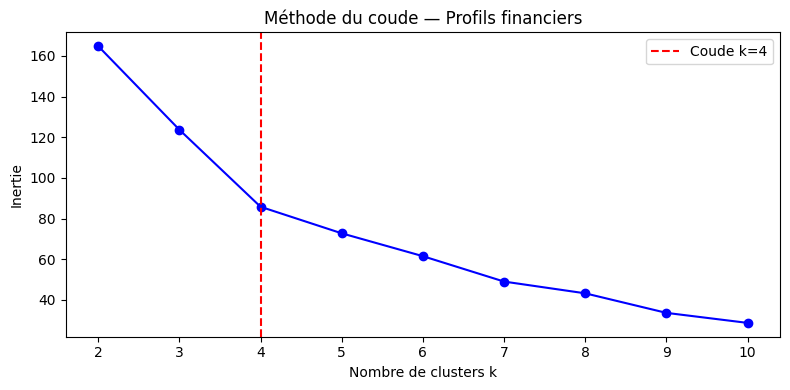

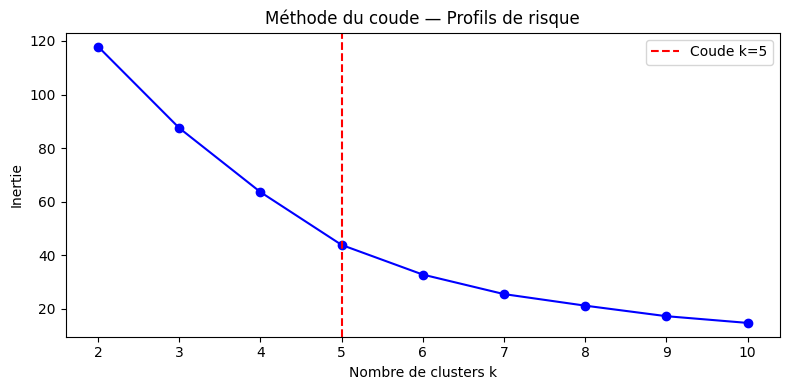

k optimal financier : 4 | k optimal risque : 5


In [7]:
def elbow_method(data: np.ndarray, k_max: int = 10, title: str = "") -> int:
    """Trace la courbe d'inertie et retourne le k optimal (coude)."""
    inertias = []
    ks = range(2, k_max + 1)
    for k in ks:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(data)
        inertias.append(km.inertia_)

    # Détection automatique du coude (différence de pente)
    diffs = np.diff(inertias)
    diffs2 = np.diff(diffs)
    elbow_k = int(ks[np.argmax(diffs2) + 1])

    plt.figure(figsize=(8, 4))
    plt.plot(list(ks), inertias, 'bo-')
    plt.axvline(x=elbow_k, color='red', linestyle='--', label=f'Coude k={elbow_k}')
    plt.xlabel('Nombre de clusters k')
    plt.ylabel('Inertie')
    plt.title(f'Méthode du coude {title}')
    plt.legend()
    plt.tight_layout()
    plt.show()
    return elbow_k


k_financial = elbow_method(financial_scaled, title="— Profils financiers")
k_risk      = elbow_method(risk_scaled,      title="— Profils de risque")
print(f"k optimal financier : {k_financial} | k optimal risque : {k_risk}")


=== KMeans Profils financiers — k=4 ===
cluster
0    19
1    16
2     2
3     2
Name: count, dtype: int64


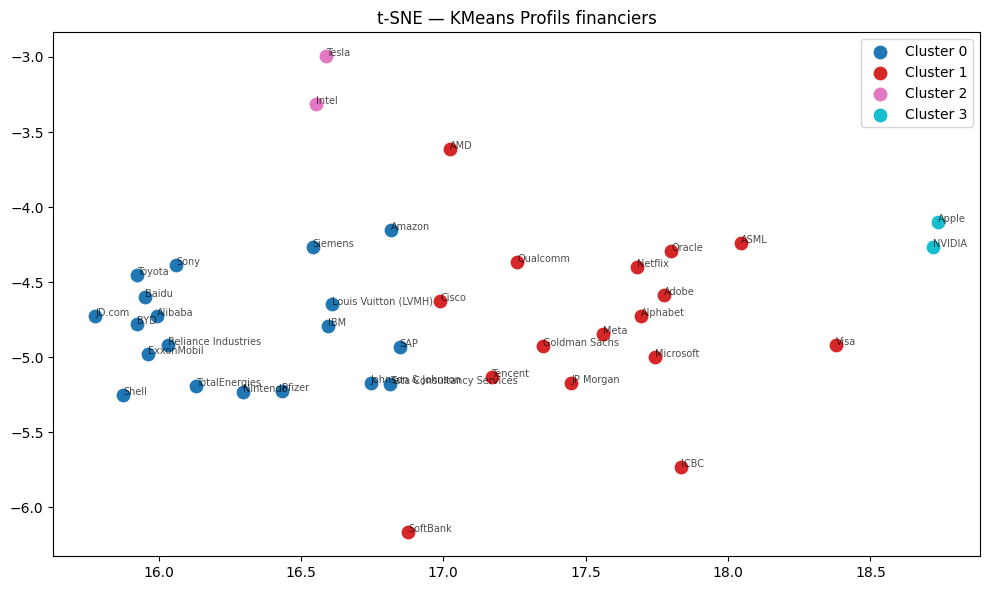


=== KMeans Profils de risque — k=5 ===
cluster
0     4
1    14
2     1
3     9
4     2
Name: count, dtype: int64


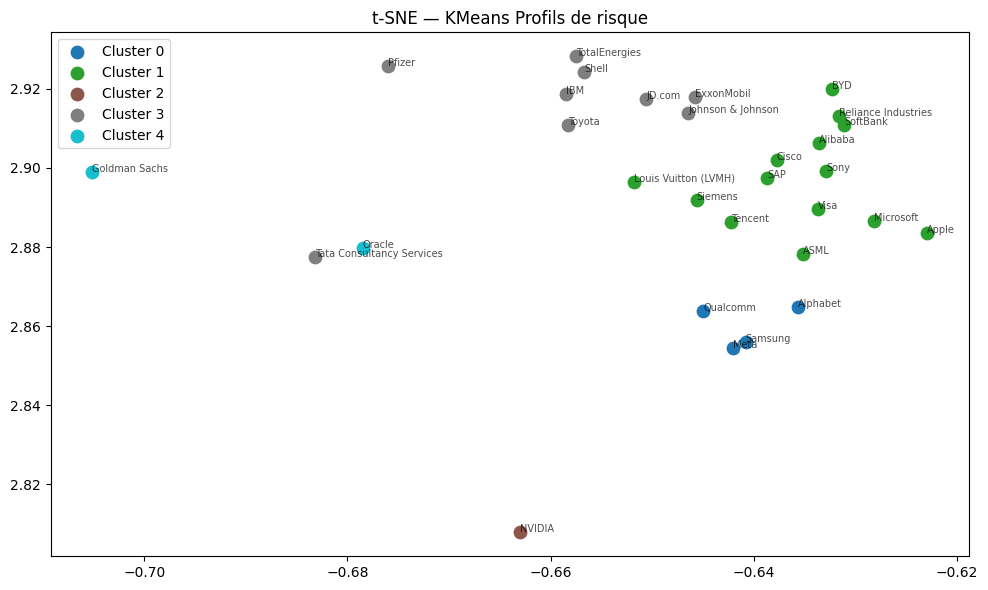

In [8]:
def do_kmeans_clustering(data: np.ndarray, labels: list, 
                         k: int, title: str = "") -> pd.DataFrame:
    """Applique KMeans, affiche les statistiques et la projection t-SNE."""
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(data)

    result_df = pd.DataFrame(data)
    result_df["cluster"] = cluster_labels

    print(f"\n=== KMeans {title} — k={k} ===")
    print(result_df["cluster"].value_counts().sort_index())

    # t-SNE
    perp = min(30, max(2, len(data) - 1))
    tsne = TSNE(n_components=2, random_state=42, perplexity=perp)
    tsne_coords = tsne.fit_transform(data)

    cmap = plt.cm.get_cmap('tab10', k)
    plt.figure(figsize=(10, 6))
    for c in range(k):
        mask = cluster_labels == c
        plt.scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
                    color=cmap(c), label=f"Cluster {c}", s=80)
        for i, txt in enumerate(np.array(labels)[mask]):
            plt.annotate(txt, (tsne_coords[mask][i, 0], tsne_coords[mask][i, 1]),
                         fontsize=7, alpha=0.7)
    plt.title(f't-SNE — KMeans {title}')
    plt.legend()
    plt.tight_layout()
    plt.show()
    return result_df


kmeans_financial_df = do_kmeans_clustering(
    financial_scaled, financial_labels, k_financial, "Profils financiers")

kmeans_risk_df = do_kmeans_clustering(
    risk_scaled, risk_labels, k_risk, "Profils de risque")

## 2.3 Clustering Hiérarchique + Dendrogramme


=== Hierarchical Clustering — Profils financiers ===


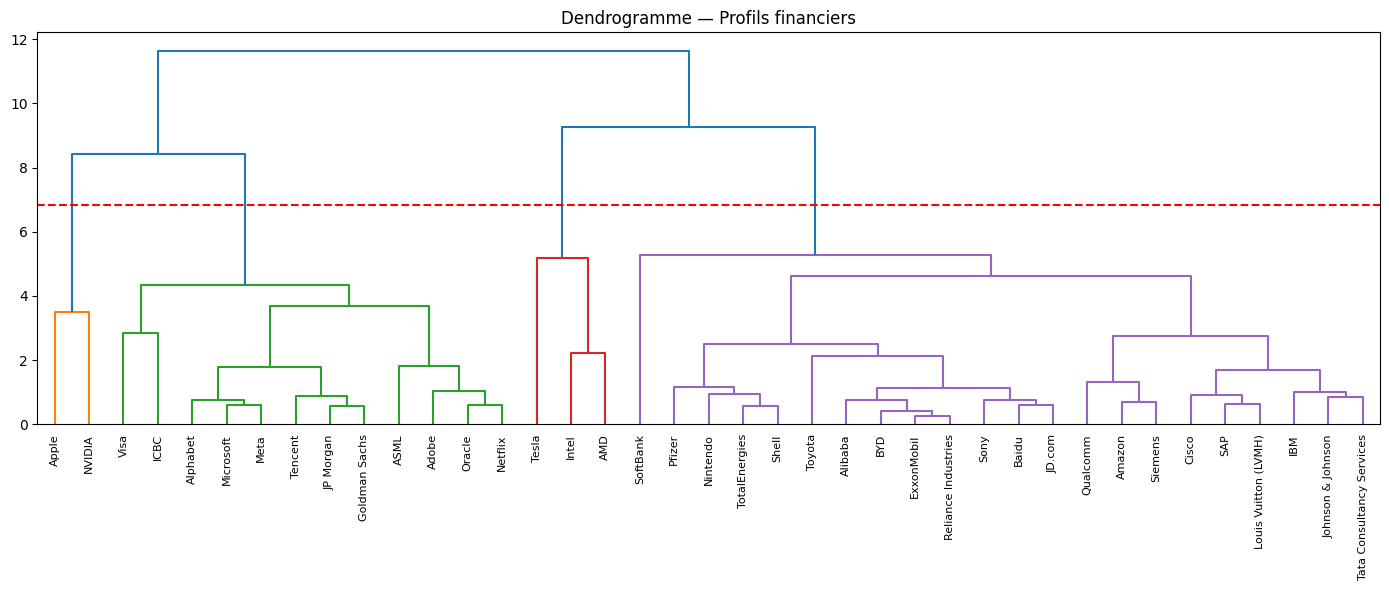

cluster
0    22
1    12
2     3
3     2
Name: count, dtype: int64

=== Hierarchical Clustering — Profils de risque ===


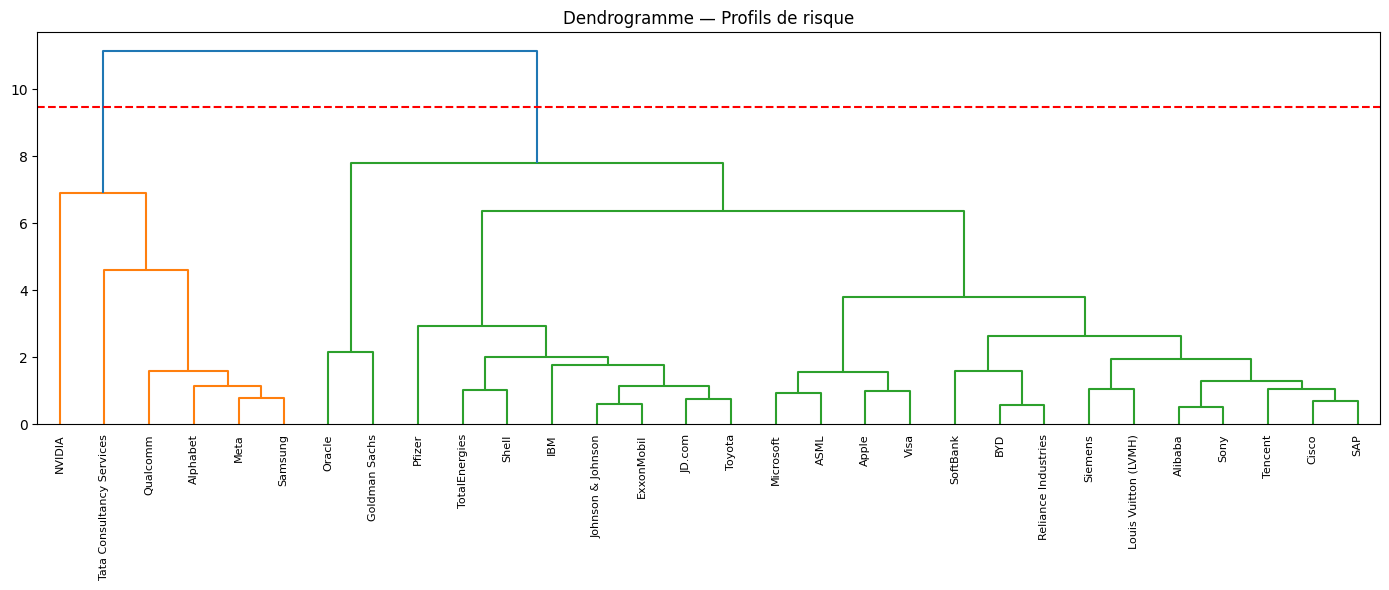

cluster
0    24
1     6
Name: count, dtype: int64


In [9]:
def plot_dendrogram(data: np.ndarray, labels: list, 
                    method: str = 'ward', title: str = ""):
    """Trace le dendrogramme du clustering hiérarchique."""
    linked = linkage(data, method=method)
    distances = linked[:, 2]
    sauts = np.diff(distances)
    idx_max_saut = np.argmax(sauts) 

    # Le nombre de clusters idéal correspond à (Nombre de points - index du saut maximal - 1)
    # Pour des raisons de stabilité analytique, on contraint K entre 2 et 6 clusters max.
    optimal_k = len(data) - (idx_max_saut + 1)
    optimal_k = max(2, min(optimal_k, 6))

    # Calculer la hauteur de coupure (seuil de distance) au milieu du plus grand saut
    h_coupure = (distances[idx_max_saut] + distances[idx_max_saut + 1]) / 2

    plt.figure(figsize=(14, 6))
    dendrogram(linked, labels=labels, color_threshold=h_coupure, leaf_rotation=90, leaf_font_size=8)
    # Ajout d'une ligne horizontale rouge indiquant la coupure optimale calculée
    plt.axhline(y=h_coupure, color='r', linestyle='--', label=f'Coupure optimale (K={optimal_k})')
    plt.title(f'Dendrogramme — {title}')
    plt.tight_layout()
    plt.show()
    return linked, optimal_k


def do_hierarchical_clustering(data: np.ndarray, labels: list,
                               method: str = 'ward', title: str = "") -> pd.DataFrame:
    """Clustering hiérarchique AgglomerativeClustering + dendrogramme."""
    print(f"\n=== Hierarchical Clustering — {title} ===")
    linked, optimal_k = plot_dendrogram(data, labels, method, title)

    agg = AgglomerativeClustering(n_clusters=optimal_k, linkage=method)
    cluster_labels = agg.fit_predict(data)

    result_df = pd.DataFrame(data, index=labels)
    result_df["cluster"] = cluster_labels

    print(result_df["cluster"].value_counts().sort_index())
    return result_df


hierarchical_financial_df = do_hierarchical_clustering(
    financial_scaled, financial_labels, method='ward', title="Profils financiers")

hierarchical_risk_df = do_hierarchical_clustering(
    risk_scaled, risk_labels, method='ward', title="Profils de risque")

## 2.4 Clustering sur les corrélations de rendements journaliers

Matrice de corrélation calculée sur 41 entreprises.

=== Hierarchical Clustering — Rendements quotidiens ===


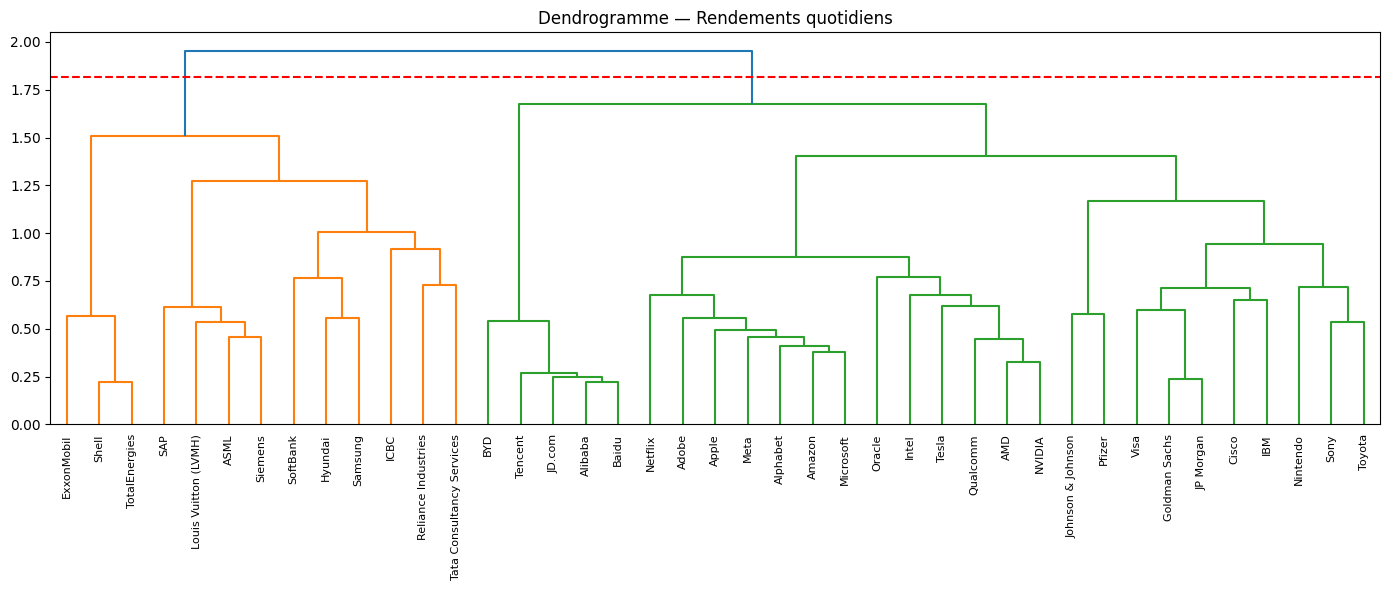

In [10]:
def prepare_daily_returns_df(directory_pattern="companies_historical_data/*.csv"):
    """
    Préparation des Rendements des entreprises et matrice de corrélation.
    """
    returns_dict = {}
    filepaths = glob.glob(directory_pattern)
    
    for path in filepaths:
        company_name = os.path.basename(path).replace(".csv", "")
        try:
            df_hist = pd.read_csv(path, index_col=0)
            if "Daily Return" in df_hist.columns:
                returns_dict[company_name] = df_hist["Daily Return"]
        except Exception as e:
            print(f"Erreur lors de la lecture du fichier de {company_name}: {e}")
            
    returns_df = pd.DataFrame(returns_dict)
    returns_df = returns_df.fillna(returns_df.mean())
    correlation_matrix = returns_df.corr()
    
    print(f"Matrice de corrélation calculée sur {correlation_matrix.shape[0]} entreprises.")
    return correlation_matrix

def cluster_by_returns_correlation(correlation_matrix: pd.DataFrame):
    """Clustering hiérarchique sur la matrice de corrélation des rendements."""
    print(f"\n=== Hierarchical Clustering — Rendements quotidiens ===")
    distance_matrix = 1 - correlation_matrix
    condensed = squareform(distance_matrix.values, checks=False)

    labels = correlation_matrix.columns.tolist()

    linked, optimal_k = plot_dendrogram(condensed, labels, "ward", "Rendements quotidiens")

    cluster_assignments = fcluster(linked, t=optimal_k, criterion='maxclust')
    return pd.Series(cluster_assignments, index=labels, name="cluster")

correlation_matrix = prepare_daily_returns_df()
hierarchical_daily_df = cluster_by_returns_correlation(correlation_matrix)

## 2.5 DBSCAN + tableau de comparaison des Silhouette Scores

In [11]:
def do_dbscan_clustering(data: np.ndarray, labels: list, eps: float = 0.5,
                         min_samples: int = 2, title: str = "") -> np.ndarray:
    """Applique DBSCAN et retourne les labels de clusters."""
    print(f"\n=== DBSCAN Clustering (eps={eps}, min_samples={min_samples}) — {title} ===")    
    best_eps = eps
    best_labels = None
    n_clusters = 0
    
    # Grille de recherche adaptative (ajustée selon la nature des données)
    # Si les distances maximales sont petites (cas des rendements <= 2.0), on cherche très bas.
    is_correlation = "Corr" in title or "Rendements" in title
    
    if is_correlation:
        grille_eps = [0.5, 0.4, 0.35, 0.3, 0.25, 0.55, 0.6]
    else:
        grille_eps = [1.5, 1.2, 1.0, 0.8, 1.8, 2.0, 2.2]

    for test_eps in [eps] + grille_eps:
        dbscan = DBSCAN(eps=test_eps, min_samples=min_samples)
        lbls = dbscan.fit_predict(data)
        
        # Compter les clusters uniques trouvés (en excluant le bruit -1)
        unique_lbls = set(lbls)
        test_n_clusters = len(unique_lbls) - (1 if -1 in unique_lbls else 0)
        
        # Si on trouve au moins 2 clusters réels, la configuration est validée !
        if test_n_clusters >= 2:
            best_eps = test_eps
            best_labels = lbls
            n_clusters = test_n_clusters
            break
            
    # Si aucune combinaison ne trouve de clusters multiples, on garde la dernière tentative
    if best_labels | best_labels is None:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        best_labels = dbscan.fit_predict(data)
        unique_lbls = set(best_labels)
        n_clusters = len(unique_lbls) - (1 if -1 in unique_lbls else 0)

    # Réduction de dimensionnalité t-SNE pour l'affichage
    perplexity_val = min(30, max(2, len(data) - 1))
    tsne = TSNE(n_components=2, perplexity=perplexity_val, random_state=42)
    tsne_results = tsne.fit_transform(data)
    
    # Tracé du graphique t-SNE
    plt.figure(figsize=(10, 6))
    unique_labels_final = set(best_labels)
    colors = plt.cm.get_cmap("tab10", len(unique_labels_final))
    
    for i, l in enumerate(sorted(unique_labels_final)):
        mask = (best_labels == l)
        if l == -1:
            plt.scatter(tsne_results[mask, 0], tsne_results[mask, 1], 
                        c='black', marker='x', s=90, label='Bruit (Outliers)', alpha=0.7)
        else:
            plt.scatter(tsne_results[mask, 0], tsne_results[mask, 1], 
                        color=colors(i), s=80, label=f'Cluster {l}', alpha=0.9)
            
    # Ajout du nom des entreprises sur le graphique
    for idx, company_name in enumerate(labels):
        if idx < len(tsne_results):
            plt.annotate(company_name, (tsne_results[idx, 0], tsne_results[idx, 1]), 
                         fontsize=8, alpha=0.7, xytext=(3, 3), textcoords='offset points')
        
    plt.title(f"Visualisation t-SNE DBSCAN {title}\nEps ajusté : {best_eps:.2f} | Clusters trouvés : {n_clusters}")
    plt.xlabel('Axe t-SNE 1')
    plt.ylabel('Axe t-SNE 2')
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()
    
    return best_labels

Matrice de corrélation calculée sur 41 entreprises.

EXÉCUTION DES ALGORITHMES SUR : Financial Profiles


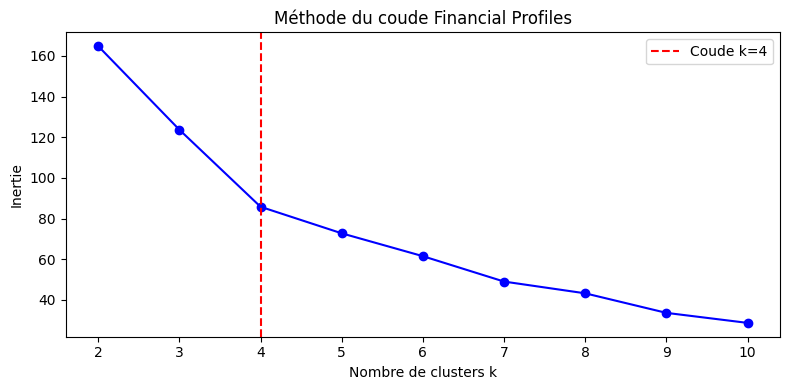


=== KMeans Financial Profiles — k=4 ===
cluster
0    19
1    16
2     2
3     2
Name: count, dtype: int64


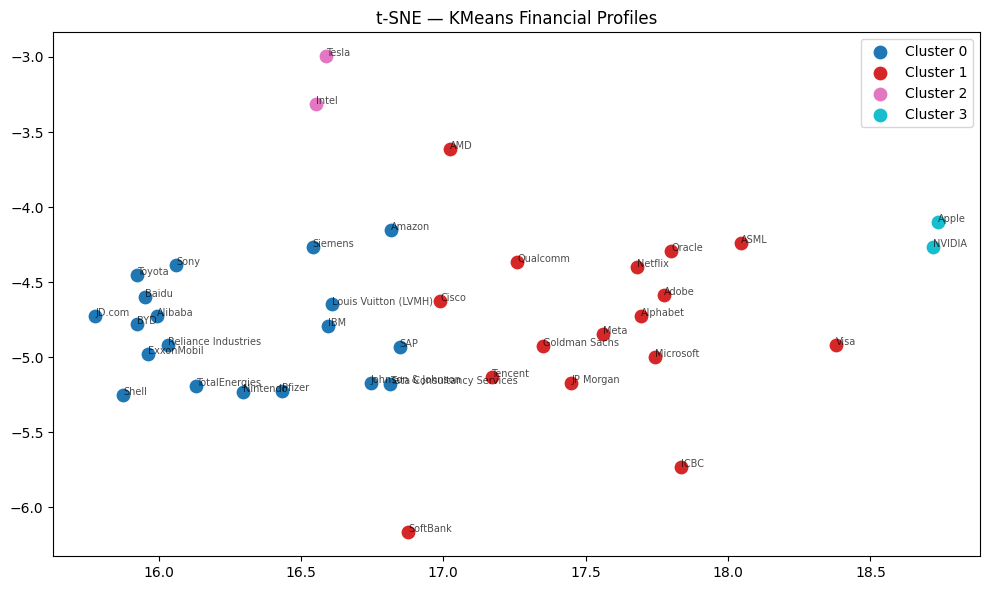

(39,)

=== Hierarchical Clustering — Financial Profiles ===


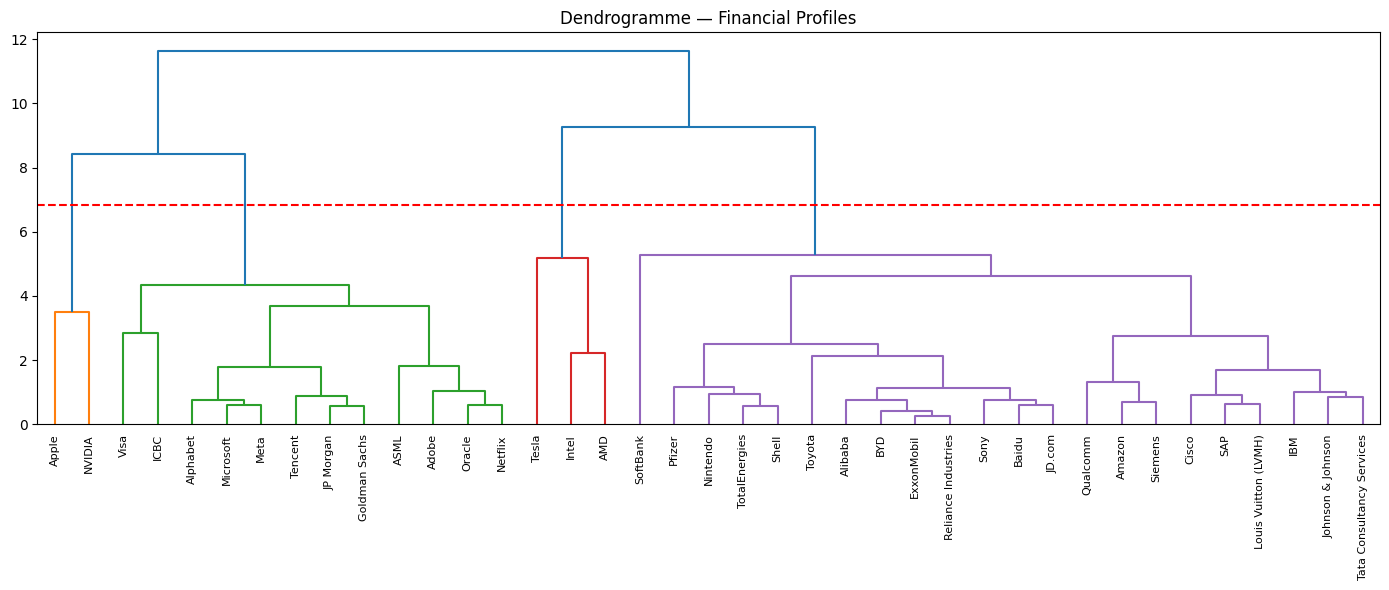

cluster
0    22
1    12
2     3
3     2
Name: count, dtype: int64

=== DBSCAN Clustering (eps=0.5, min_samples=2) — Financial Profiles ===


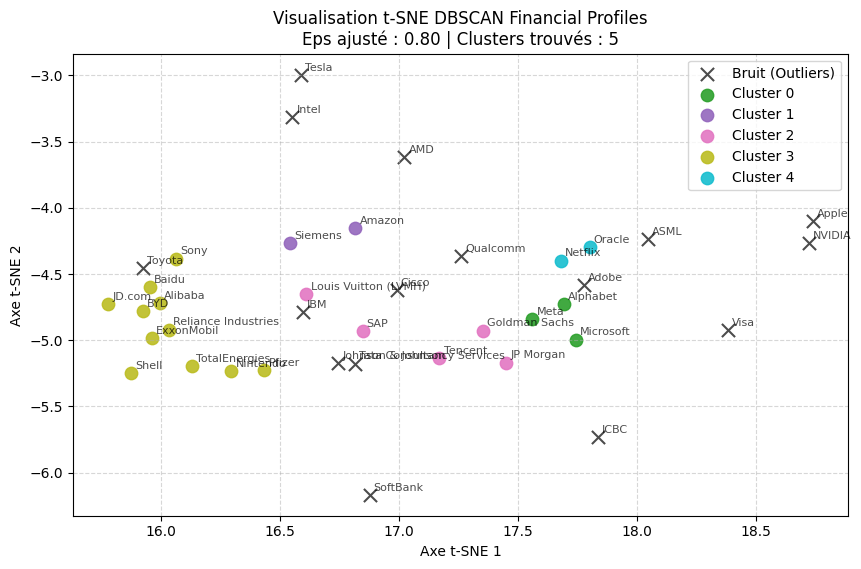


EXÉCUTION DES ALGORITHMES SUR : Risk Profiles


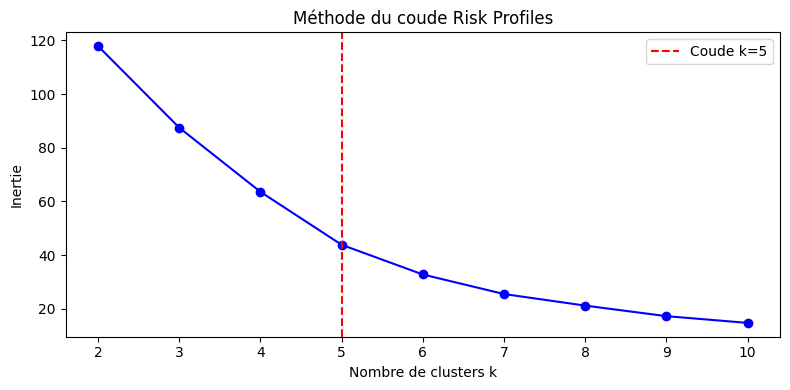


=== KMeans Risk Profiles — k=5 ===
cluster
0     4
1    14
2     1
3     9
4     2
Name: count, dtype: int64


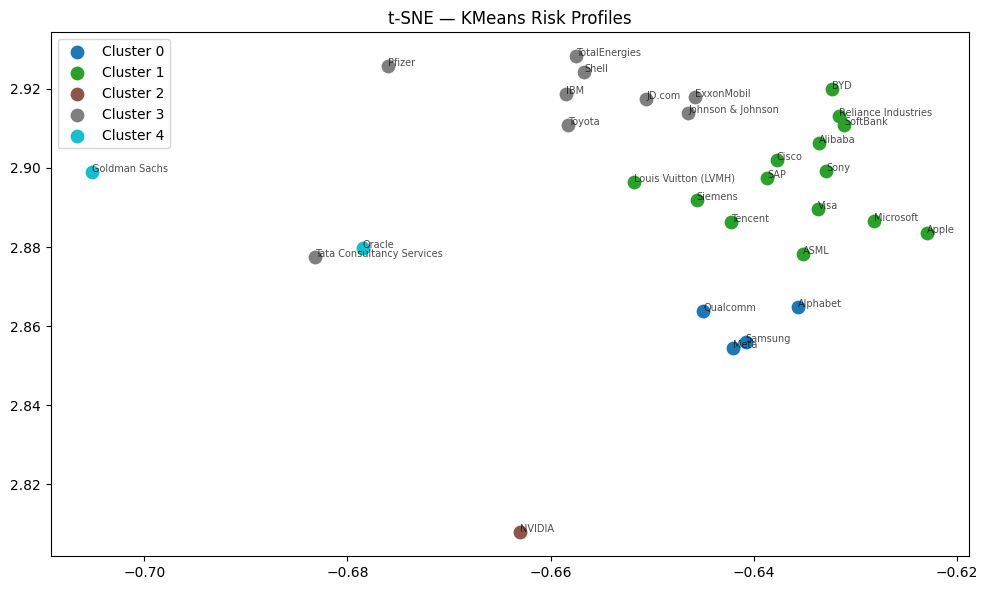

(30,)

=== Hierarchical Clustering — Risk Profiles ===


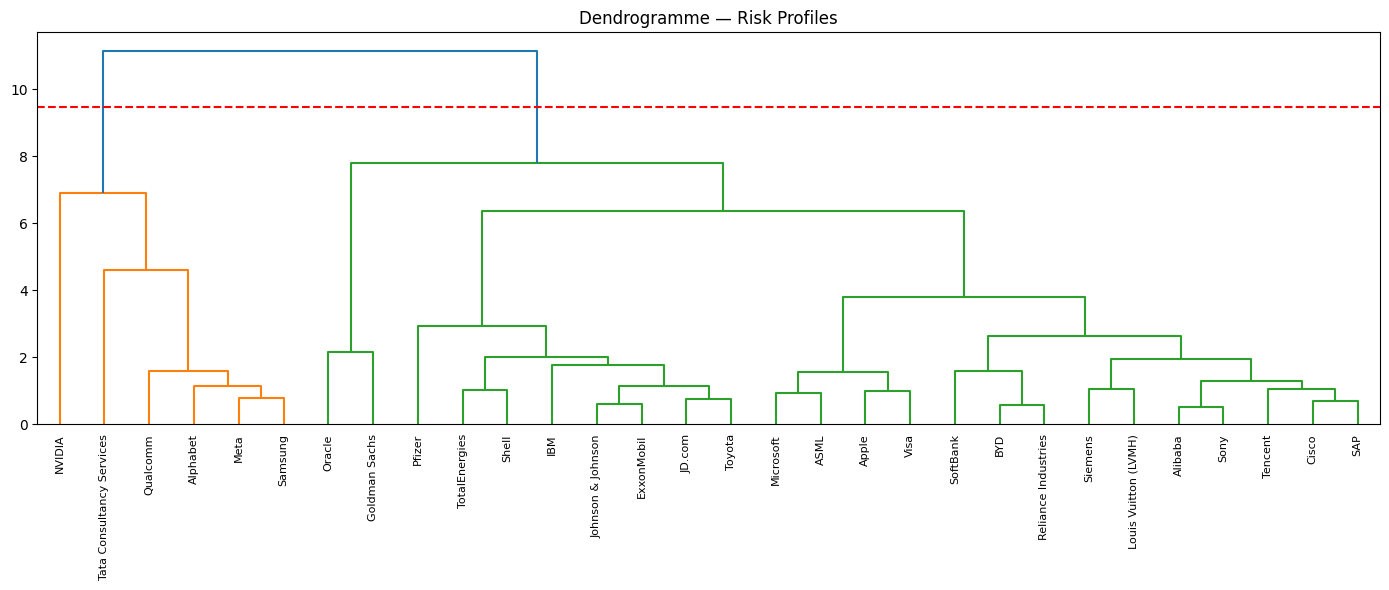

cluster
0    24
1     6
Name: count, dtype: int64

=== DBSCAN Clustering (eps=0.5, min_samples=2) — Risk Profiles ===


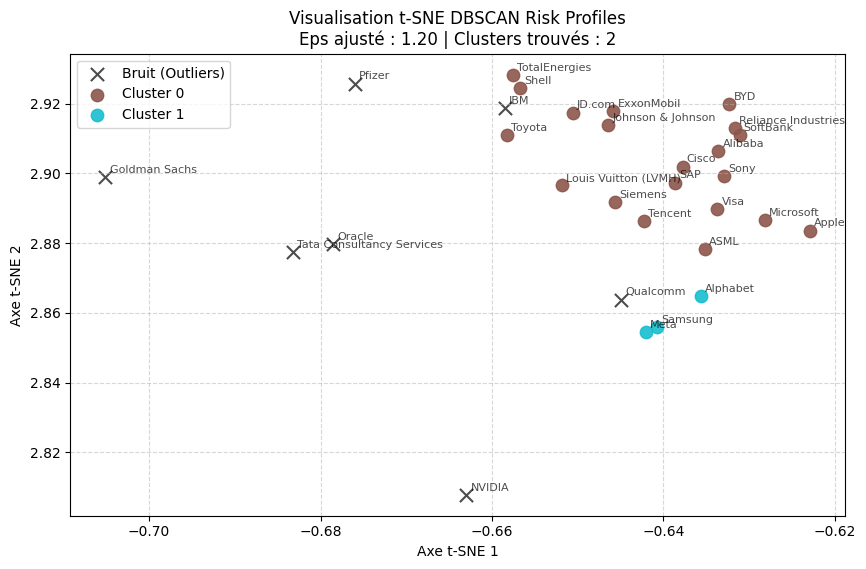


EXÉCUTION DES ALGORITHMES SUR : Daily Returns Correlation


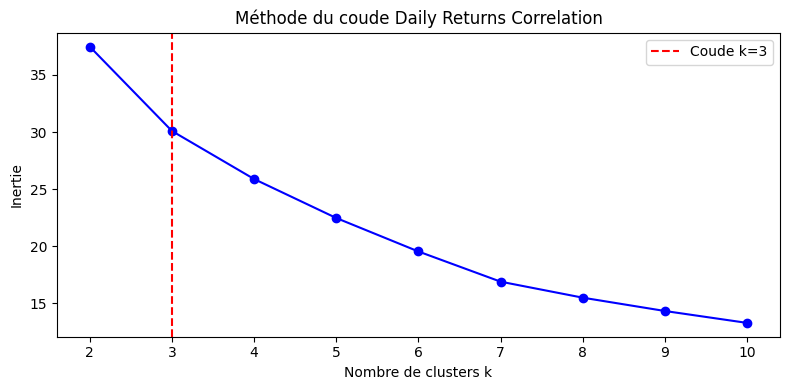


=== KMeans Daily Returns Correlation — k=3 ===
cluster
0     5
1    25
2    11
Name: count, dtype: int64


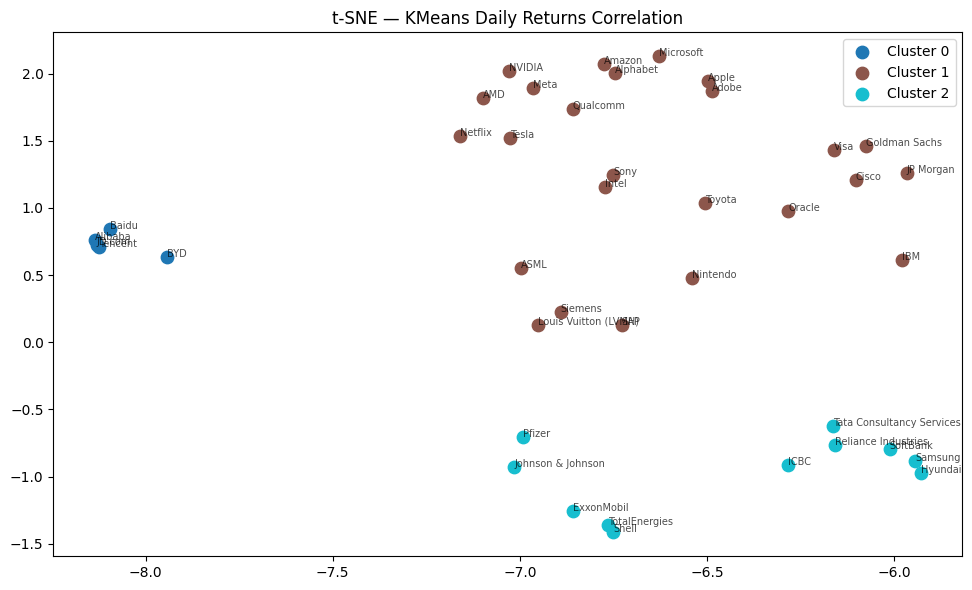

(41,)

=== Hierarchical Clustering — Rendements quotidiens ===


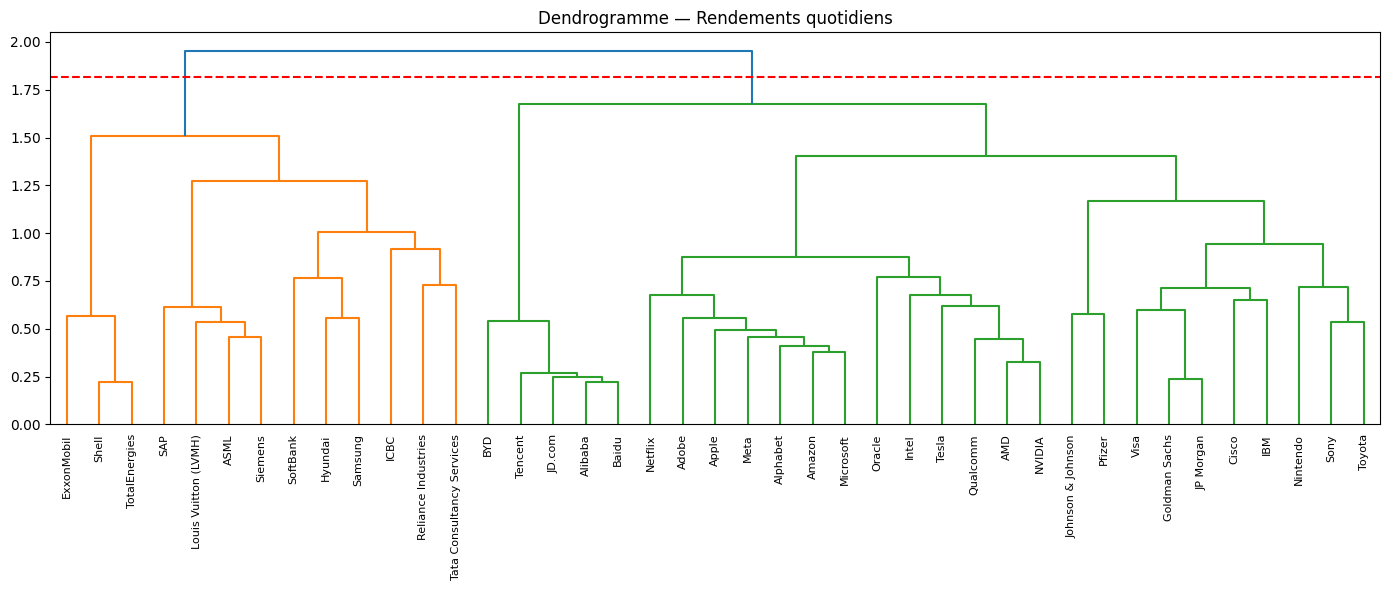


=== DBSCAN Clustering (eps=0.5, min_samples=2) — Daily Returns Correlation ===


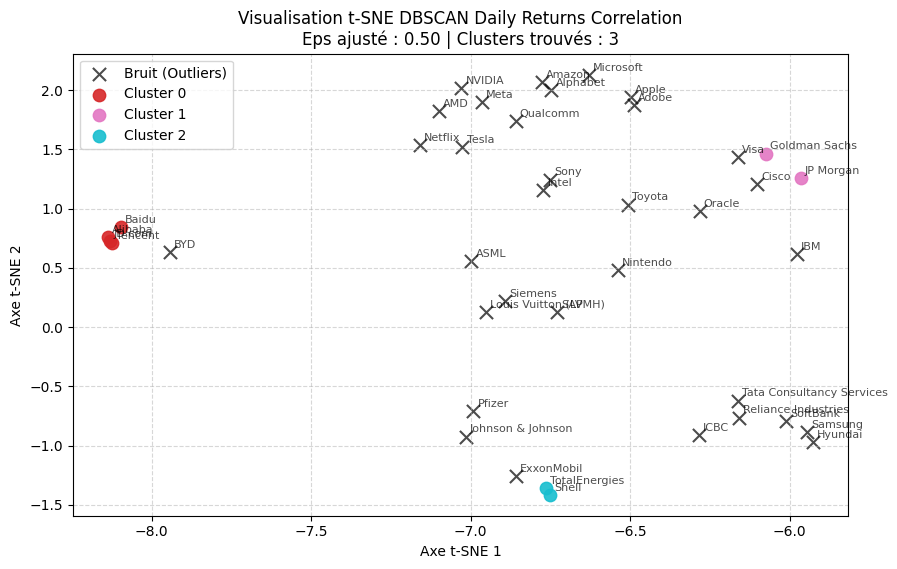


############################################################
TABLEAU DE COMPARAISON DES EVALUATIONS (SILHOUETTE SCORE)
############################################################
                    K-Means  Hierarchical  DBSCAN
Dataset                                          
Financial Profiles   0.3460        0.3443  0.3858
Risk Profiles        0.3291        0.4081  0.4633
Daily Returns Corr   0.2951        0.2819  0.7693
############################################################


In [31]:
def compare_clustering_algorithms() -> pd.DataFrame:
    """Compare KMeans, Hierarchical et DBSCAN sur chaque type de données."""
    df_financial_scaled, financial_labels = preprocess_for_financial_clustering(
        financial_ratios_df, FINANCIAL_FEATURES
    )
    df_risk_scaled, risk_labels = preprocess_for_financial_clustering(
        financial_ratios_df, RISK_FEATURES
    )
    df_returns_corr = prepare_daily_returns_df()
    
    datasets = {
        "Financial Profiles": [df_financial_scaled, financial_labels],
        "Risk Profiles": [df_risk_scaled, risk_labels],
        "Daily Returns Correlation": [df_returns_corr, df_returns_corr.columns.tolist()]
    }

    performance_matrix = {
        "Dataset": ["Financial Profiles", "Risk Profiles", "Daily Returns Corr"],
        "K-Means": [None, None, None],
        "Hierarchical": [None, None, None],
        "DBSCAN": [None, None, None]
    }

    results = {
        "Dataset" : ["Financial Profiles", "Risk Profiles", "Daily Returns Corre"],
        "K-Means" : [None, None, None],
        "Hierarchical" : [None, None, None],
        "DBSCAN" : [None, None, None]
    }

    for idx, (name, current_data) in enumerate(datasets.items()):
        print(f"\n" + "="*60 + f"\nEXÉCUTION DES ALGORITHMES SUR : {name}\n" + "="*60)
        
        # 1. Traitement K-Means 
        k_elbow = elbow_method(current_data[0], title= name)
        kmeans_labels = do_kmeans_clustering(current_data[0], current_data[1], k_elbow, title=name)["cluster"]
        print(kmeans_labels.shape)
        if len(set(kmeans_labels)) > 1:
            performance_matrix["K-Means"][idx] = silhouette_score(current_data[0], kmeans_labels)
        results["K-Means"][idx] = kmeans_labels
            
        # 2. Traitement Hierarchical Clustering 
        if name == "Daily Returns Correlation":
            hier_clustering_labels = cluster_by_returns_correlation(correlation_matrix)
        else:
            hier_clustering_labels = do_hierarchical_clustering(current_data[0], current_data[1], method='ward', title=name)["cluster"]
        if len(set(hier_clustering_labels)) > 1:
            performance_matrix["Hierarchical"][idx] = silhouette_score(current_data[0], hier_clustering_labels)
        results["Hierarchical"][idx] = hier_clustering_labels

        # 3. Traitement DBSCAN
        dbscan_labels = do_dbscan_clustering(current_data[0], current_data[1], title=name)
        
        valid_mask = dbscan_labels != -1
        if len(set(dbscan_labels[valid_mask])) > 1 and np.sum(valid_mask) > 1:
            performance_matrix["DBSCAN"][idx] = silhouette_score(current_data[0][valid_mask], dbscan_labels[valid_mask])
        else:
            performance_matrix["DBSCAN"][idx] = np.nan
        results["DBSCAN"][idx] = dbscan_labels
            
    df_summary = pd.DataFrame(performance_matrix).set_index("Dataset")
    df_results = pd.DataFrame(results).set_index("Dataset")

    print("\n" + "#"*60 + "\nTABLEAU DE COMPARAISON DES EVALUATIONS (SILHOUETTE SCORE)\n" + "#"*60)
    print(df_summary.round(4))
    print("#"*60)
    
    return df_summary, df_results

# Lancement de l'analyse globale
tableau_comparatif_final, clustering_results = compare_clustering_algorithms()

---
# TP3 — Classification Buy / Hold / Sell
## 3.1 Création des labels

In [ ]:
def create_classification_labels(df: pd.DataFrame) -> pd.DataFrame:
    """Crée les labels buy/hold/sell à partir du rendement sur 20 jours."""
    df = df[["Close"]].copy()
    df["Close Horizon"] = df["Close"].shift(-20)
    df["horizon_return"] = (df["Close Horizon"] - df["Close"]) / df["Close"]
    df["Label"] = df["horizon_return"].apply(
        lambda r: 2 if r > 0.05 else (0 if r < -0.05 else 1)
    )
    return df.dropna()


def add_technical_indicators(df: pd.DataFrame) -> pd.DataFrame:
    """Ajoute les indicateurs techniques via la librairie ta."""
    c = df["Close"]
    df["SMA_20"]          = ta.trend.sma_indicator(c, window=20)
    df["EMA_20"]          = ta.trend.ema_indicator(c, window=20)
    df["RSI_14"]          = ta.momentum.rsi(c, window=14)
    macd                  = ta.trend.MACD(c)
    df["MACD"]            = macd.macd()
    df["MACD_Signal"]     = macd.macd_signal()
    bb                    = ta.volatility.BollingerBands(c, window=20)
    df["Bollinger_High"]  = bb.bollinger_hband()
    df["Bollinger_Low"]   = bb.bollinger_lband()
    df["Rolling_Volatility"] = c.rolling(20).std()
    df["ROC_10"]          = ta.momentum.roc(c, window=10)
    return df


def build_classification_dataset(historical_data: dict) -> tuple:
    """Construit le dataset de classification (toutes entreprises concaténées)."""
    all_frames = []
    for company_name, df in historical_data.items():
        try:
            labeled   = create_classification_labels(df)
            with_tech = add_technical_indicators(labeled)
            with_tech.dropna(inplace=True)
            all_frames.append(with_tech)
        except Exception as e:
            print(f"  ✘ {company_name}: {e}")

    full_df = pd.concat(all_frames)

    drop_cols = [c for c in ["Label", "Close Horizon", "horizon_return",
                              "Next Day Close", "Daily Return"] if c in full_df.columns]
    X = full_df.drop(columns=drop_cols)
    y = full_df["Label"]

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"Dataset : {full_df.shape} | Train : {X_train.shape} | Test : {X_test.shape}")
    return X_train, X_test, y_train, y_test, X


X_train_cls, X_test_cls, y_train_cls, y_test_cls, X_cls = build_classification_dataset(historical_data)

Close                 float64
SMA_20                float64
EMA_20                float64
RSI_14                float64
MACD                  float64
MACD_Signal           float64
Bollinger_High        float64
Bollinger_Low         float64
Rolling_Volatility    float64
ROC_10                float64
dtype: object
Dataset : (49151, 13) | Train : (39320, 10) | Test : (9831, 10)


## 3.2 Algorithmes de classification

In [35]:
tscv = TimeSeriesSplit(n_splits=5, gap=1)

In [ ]:
def train_classifier(model, param_grid, X_train, y_train, X_test, y_test, model_name):
    """Grid + évaluation d'un classifieur."""
    grid = GridSearchCV(
        model, param_grid,
        cv=tscv,
        scoring='f1_macro',   # mieux qu'accuracy pour classes déséquilibrées
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred     = best_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')

    print(f"\n{'='*50}")
    print(f"  {model_name} — Accuracy : {acc:.4f}  F1-macro : {f1:.4f}")
    print(f"  Meilleurs hyperparamètres : {grid.best_params_}")
    print(classification_report(y_test, y_pred, target_names=["Sell", "Hold", "Buy"]))

    return {"model": best_model, "accuracy": acc, "f1_macro": round(f1, 4), "name": model_name}

In [42]:
# XGBoost
xgb_cls_result = train_classifier(
    XGBClassifier(eval_metric='mlogloss'),
    {
        "n_estimators":  [100, 200, 300, 500],
        "max_depth":     [2, 3, 4, 5],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "subsample":     [0.7, 0.8, 1.0],
    },
    X_train_cls, y_train_cls, X_test_cls, y_test_cls, "XGBoost"
)


  XGBoost — Accuracy : 0.6221  F1-macro : 0.5949
  Meilleurs hyperparamètres : {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 500, 'subsample': 1.0}
              precision    recall  f1-score   support

        Sell       0.64      0.44      0.53      2335
        Hold       0.61      0.78      0.68      4493
         Buy       0.64      0.52      0.57      3003

    accuracy                           0.62      9831
   macro avg       0.63      0.58      0.59      9831
weighted avg       0.63      0.62      0.61      9831



In [43]:
# Random Forest
rf_cls_result = train_classifier(
    RandomForestClassifier(),
    {
        "n_estimators":    [100, 200, 300],
        "min_samples_leaf":[1, 5, 10],
        "max_features":    ["sqrt", 0.5],
    },
    X_train_cls, y_train_cls, X_test_cls, y_test_cls, "Random Forest"
)


  Random Forest — Accuracy : 0.7588  F1-macro : 0.7516
  Meilleurs hyperparamètres : {'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}
              precision    recall  f1-score   support

        Sell       0.79      0.67      0.72      2335
        Hold       0.74      0.82      0.78      4493
         Buy       0.78      0.74      0.76      3003

    accuracy                           0.76      9831
   macro avg       0.77      0.74      0.75      9831
weighted avg       0.76      0.76      0.76      9831



In [59]:
# Logistic Regression
lr_cls_result = train_classifier(
    LogisticRegression(max_iter=1000),
    {
        "C": [0.01, 0.1, 1, 10, 100], 
        "penalty": ["l1", "l2", "elastticnet"],
        "solver" : ["liblinear", "saga", "lbfgs"]
    },
    X_train_cls, y_train_cls, X_test_cls, y_test_cls, "Logistic Regression"
)


  Logistic Regression — Accuracy : 0.4581  F1-macro : 0.2125
  Meilleurs hyperparamètres : {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
              precision    recall  f1-score   support

        Sell       0.00      0.00      0.00      2335
        Hold       0.46      1.00      0.63      4493
         Buy       0.79      0.00      0.01      3003

    accuracy                           0.46      9831
   macro avg       0.42      0.33      0.21      9831
weighted avg       0.45      0.46      0.29      9831



In [60]:
# KNN
knn_cls_result = train_classifier(
    KNeighborsClassifier(n_jobs=-1),
    {
        "n_neighbors": [3, 5, 10, 20],
        "weights":     ["uniform", "distance"],
        "metric":      ["euclidean", "manhattan", "minkowski"],
    },
    X_train_cls, y_train_cls, X_test_cls, y_test_cls, "KNN"
)


  KNN — Accuracy : 0.4162  F1-macro : 0.3830
  Meilleurs hyperparamètres : {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
              precision    recall  f1-score   support

        Sell       0.29      0.26      0.27      2335
        Hold       0.50      0.55      0.52      4493
         Buy       0.36      0.34      0.35      3003

    accuracy                           0.42      9831
   macro avg       0.38      0.38      0.38      9831
weighted avg       0.41      0.42      0.41      9831



In [61]:
# SVM
svm_cls_result = train_classifier(
    LinearSVC(max_iter=2000),
    {
        "C": [0.001, 0.01, 0.1, 1.0, 10.0],
        "penalty": ["l1", "l2"]
    },
    X_train_cls, y_train_cls, X_test_cls, y_test_cls, "SVM (Linear)"
)


  SVM (Linear) — Accuracy : 0.4577  F1-macro : 0.2118
  Meilleurs hyperparamètres : {'C': 10.0, 'penalty': 'l2'}
              precision    recall  f1-score   support

        Sell       0.00      0.00      0.00      2335
        Hold       0.46      1.00      0.63      4493
         Buy       0.71      0.00      0.01      3003

    accuracy                           0.46      9831
   macro avg       0.39      0.33      0.21      9831
weighted avg       0.42      0.46      0.29      9831



In [62]:
def run_shap(model_name, model, X_test, feature_names, classes=["Sell", "Hold", "Buy"], n_samples=500):
    print(f"\n=== SHAP — Explication du modèle {model_name} ===")
    try:

        def plot_shap(shap_values, X_test):
            sv = np.array(shap_values)
            for i, label in enumerate(classes):
                print(f"SHAP — Importance pour '{label}' (classe {i}) :")
                shap.summary_plot(sv[:, :, i], X_test, feature_names=feature_names)

        if "XGBoost" in model_name or "RandomForest" in model_name:
            explainer   = shap.TreeExplainer(model)
        elif "KNN" in model_name or "SVM" in model_name:  # permutation pour KNN et SVM
            explainer = shap.KernelExplainer(model.predict, X_test)
        elif "Logistic" in model_name:
            explainer = shap.LinearExplainer(model, X_test)
        else:
            print(f"  ⚠ Modèle '{model_name}' non reconnu")

        shap_values = explainer.shap_values(X_test)
        plot_shap(shap_values, X_test)

    except Exception as e:
        print(f"  Analyse non disponible pour {model_name} : {e}")

In [63]:
run_shap("XGBoost",            xgb_cls_result["model"], X_test_cls, X_cls.columns)


=== SHAP — Explication du modèle XGBoost ===
  Analyse non disponible pour XGBoost : could not convert string to float: '[-3.021226E-1,3.525983E-1,-5.0475955E-2]'



=== SHAP — Explication du modèle RandomForest ===
SHAP — Importance pour 'Sell' (classe 0) :


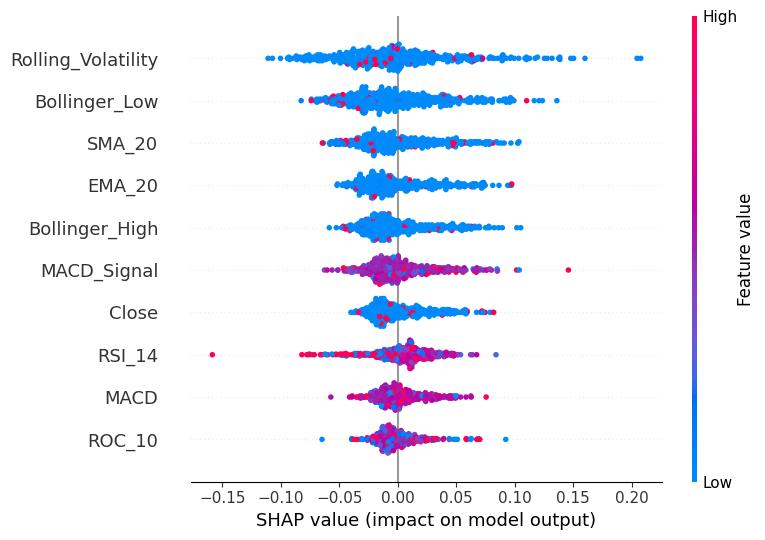

SHAP — Importance pour 'Hold' (classe 1) :


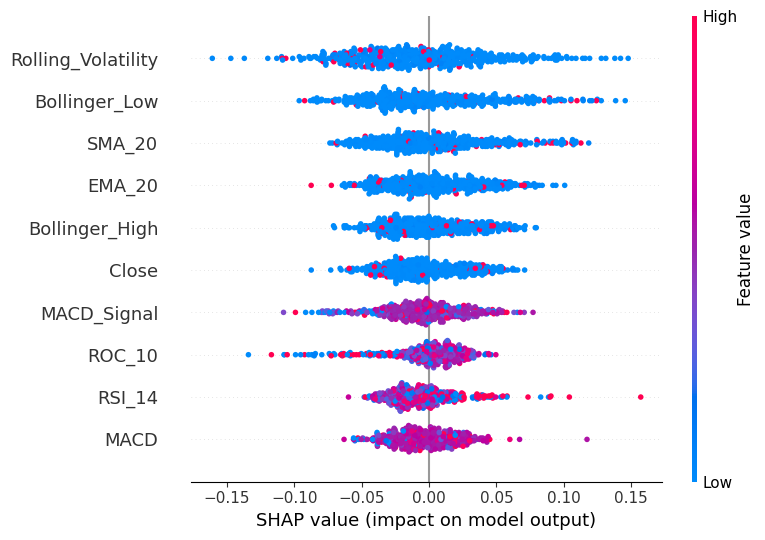

SHAP — Importance pour 'Buy' (classe 2) :


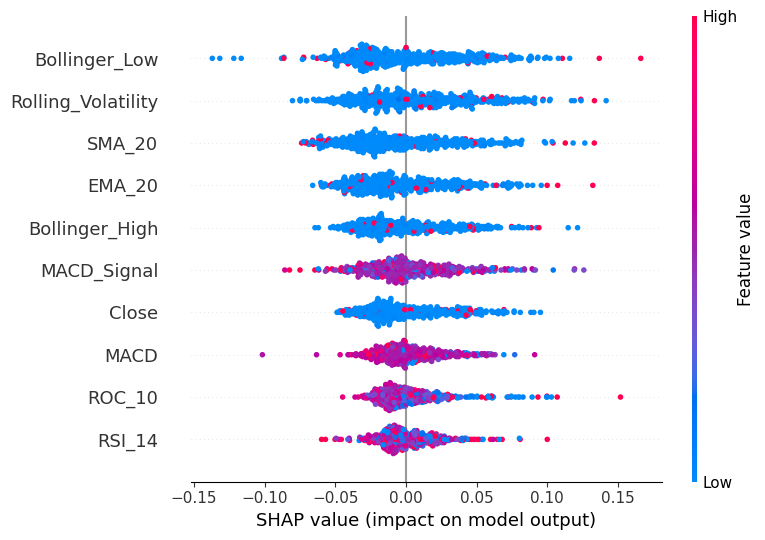

In [ ]:
run_shap("RandomForest",       rf_cls_result["model"],  X_test_cls, X_cls.columns)


=== SHAP — Explication du modèle LogisticRegression ===
SHAP — Importance pour 'Sell' (classe 0) :


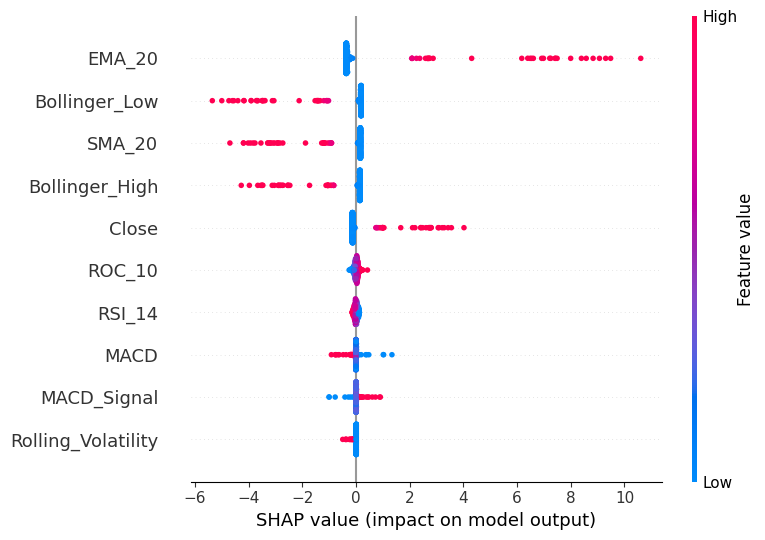

SHAP — Importance pour 'Hold' (classe 1) :


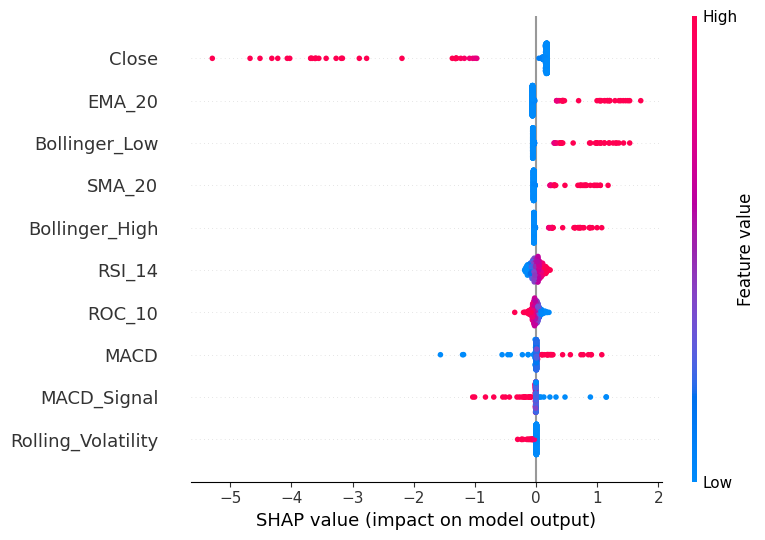

SHAP — Importance pour 'Buy' (classe 2) :


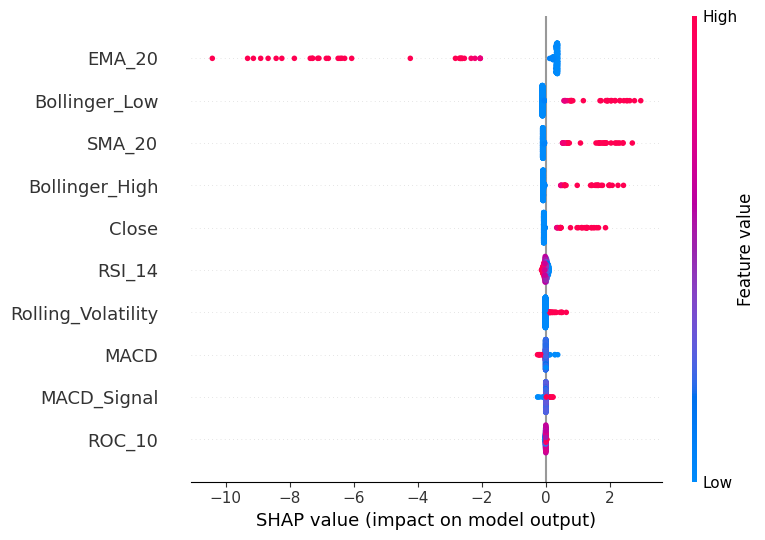

In [24]:
run_shap("LogisticRegression", lr_cls_result["model"],  X_test_cls, X_cls.columns, class_labels)


=== SHAP — Explication du modèle SVM ===
  Permutation Importance — SVM :


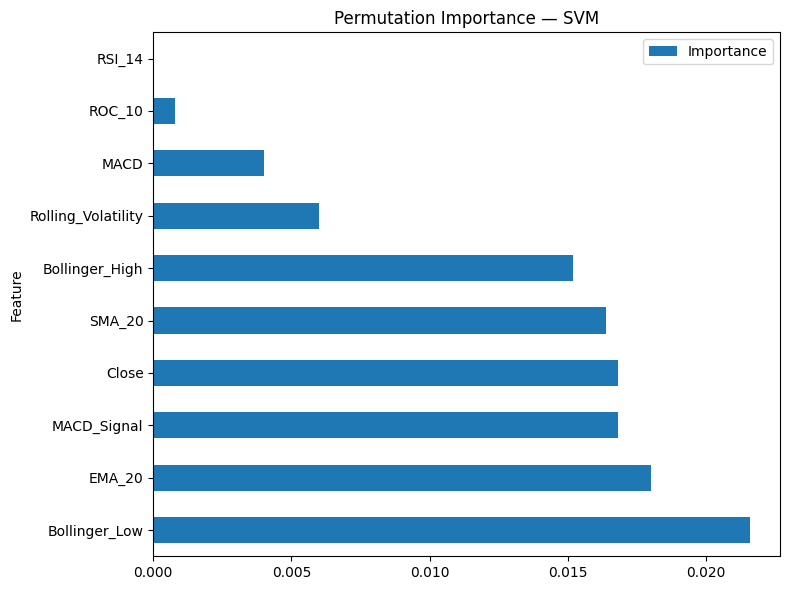

In [25]:
run_shap("SVM", svm_cls_result["model"], X_test_cls, X_cls.columns, class_labels)


=== SHAP — Explication du modèle KNN ===
  Permutation Importance — KNN :


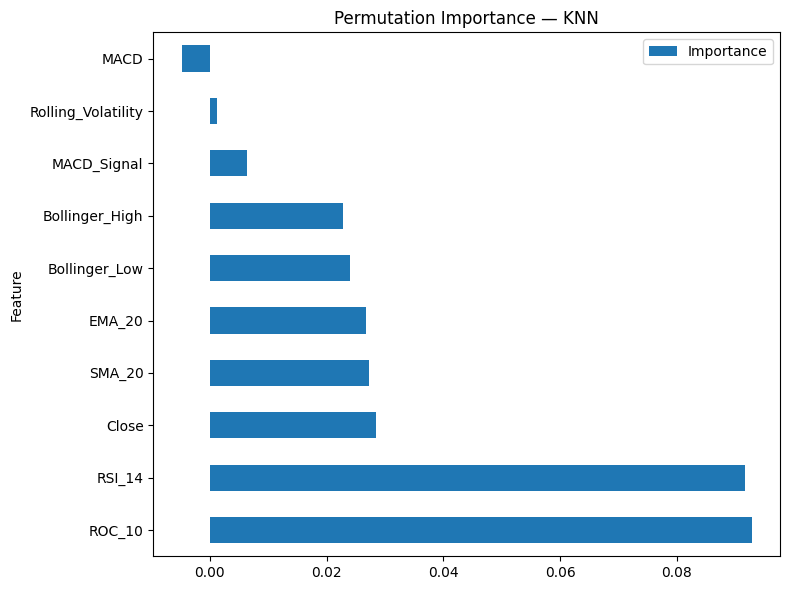

In [26]:
run_shap("KNN",                knn_cls_result["model"], X_test_cls, X_cls.columns, class_labels)

In [27]:
# Tableau récapitulatif — Classification
cls_perf_df = pd.DataFrame([
    {"Modèle": r["name"], "Accuracy": round(r["accuracy"], 4), "F1-macro": r["f1_macro"]}
    for r in [xgb_cls_result, rf_cls_result, knn_cls_result,
               lr_cls_result, svm_cls_result]
]).sort_values("F1-macro", ascending=False)  # trier par F1-macro
print("\n=== Tableau comparatif — Classification ===")
cls_perf_df


=== Tableau comparatif — Classification ===


,Modèle,Accuracy,F1-macro
1,Random Forest,0.7608,0.7540
0,XGBoost,0.5856,0.5492
2,KNN,0.4162,0.3830
3,Logistic Regression,0.4580,0.2125
4,SVM (Linear),0.4577,0.2118


---
# TP4 — Régression (prédiction J+1)
## 4.1 Préparation du dataset de régression

In [ ]:
N_DAYS = 30  # fenêtre glissante

def create_target_features(data: np.ndarray, n: int = N_DAYS) -> tuple:
    """Crée X (n jours passés) et y (J+1) à partir d'une série 1D."""
    x, y = [], []
    for i in range(n, data.shape[0]):
        x.append(data[i - n:i, 0])
        y.append(data[i, 0])
    return np.array(x), np.array(y)

def prepare_regression_data(df: pd.DataFrame, n: int = N_DAYS) -> dict:
    """Prépare les données de régression pour une entreprise."""
    close = df[["Close"]].values
    scaler = MinMaxScaler()

    split_idx = int(len(close) * 0.8)
    train_raw = close [:split_idx]
    test_raw  = close[split_idx:]

    train_scaled = scaler.fit_transform(train_raw)
    # Pour le test, on inclut les n derniers jours du train pour ne rien perdre ! 
    test_context = np.vstack([train_raw[-n:], test_raw])
    test_scaled = scaler.transform(test_context)

    X_train, y_train = create_target_features(train_scaled, n)
    X_test,  y_test  = create_target_features(test_scaled,  n)

    return {
        "X_train": X_train, "y_train": y_train,
        "X_test":  X_test,  "y_test":  y_test,
        "scaler":  scaler
    }


# On prend Apple comme exemple de démonstration
demo_company = "Apple"
reg_data = prepare_regression_data(historical_data[demo_company])
print(f"Données de régression ({demo_company}) — X_train : {reg_data['X_train'].shape}")

Données de régression (Apple) — X_train : (972, 30)


## 4.2 Modèles de régression ML

In [29]:
# Étape 1 : GridSearch par représentant de cluster
def find_best_regression_params(reg_data: dict) -> dict:
    """GridSearch sur un représentant de cluster pour trouver les meilleurs hyperparamètres."""
    searches = [
        (XGBRegressor(random_state=42),
            {
                "n_estimators":  [50, 100, 200, 300],
                "max_depth":     [2, 3, 5, 7],
                "learning_rate": [0.01, 0.05, 0.1, 0.2],
            },
            "XGBoost"),
        (RandomForestRegressor(random_state=42),
            {
                "n_estimators":    [50, 100, 200, 300],
                "min_samples_leaf":[1, 2, 5, 10],
                "max_features":    [0.5, "sqrt", 1.0],
            },
            "Random Forest"),
        (KNeighborsRegressor(),
            {
                "n_neighbors": [3, 5, 10, 20],
                "weights":     ["uniform", "distance"],
                "metric":      ["euclidean", "manhattan"],
            },
            "KNN"),
        (Ridge(),
            {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
            "Ridge"),
    ]

    best_params = {}
    for model, param_grid, name in searches:
        grid = GridSearchCV(model, param_grid, cv=tscv,
                            scoring='neg_mean_squared_error', n_jobs=-1)
        grid.fit(reg_data["X_train"], reg_data["y_train"])
        best_params[name] = grid.best_params_
        print(f"  {name} — meilleurs params : {best_params[name]}")

    return best_params

In [ ]:
# Étape 2 : entraîner avec les meilleurs paramètres 
def run_all_regressors(reg_data: dict, company: str, best_params: dict) -> list:
    """Entraîne les 4 régresseurs avec les meilleurs hyperparamètres trouvés."""
    models = [
        (XGBRegressor(**best_params["XGBoost"],         random_state=42), "XGBoost"),
        (RandomForestRegressor(**best_params["Random Forest"], random_state=42), "Random Forest"),
        (KNeighborsRegressor(**best_params["KNN"]),                        "KNN"),
        (Ridge(**best_params["Ridge"]),                                    "Ridge"),
    ]

    results = []
    for model, name in models:
        X_train, y_train = reg_data["X_train"], reg_data["y_train"]
        X_test,  y_test  = reg_data["X_test"],  reg_data["y_test"]
        scaler           = reg_data["scaler"]

        model.fit(X_train, y_train)
        y_pred = scaler.inverse_transform(model.predict(X_test).reshape(-1, 1)).flatten()
        y_real = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

        mae  = mean_absolute_error(y_real, y_pred)
        mse = mean_squared_error(y_real, y_pred)
        rmse = np.sqrt(mse)
        mape = mean_absolute_percentage_error(y_real, y_pred) * 100

        print(f"  {name} [{company}] — MAE={mae:.2f}  MSE={mse:.2f} RMSE={rmse:.2f}  MAPE={mape:.2f}%")
        results.append({
            "name":   name,
            "MAE":    round(mae,  2),
            "MSE":    round(mse,  2),
            "RMSE":   round(rmse, 2),
            "MAPE":   round(mape, 2),
            "y_pred": y_pred,
            "y_real": y_real,
            "model":  model
        })
    return results

In [ ]:
# Étape 3 : Application — GridSearch par cluster, entraînement sur toutes les entreprises

company_to_cluster = kmeans_financial_df["cluster"].to_dict()

# Choisir un représentant par cluster (celui avec le plus de données)
def get_cluster_representatives(company_to_cluster: dict, historical_data: dict) -> dict:
    clusters = {}
    for company, cluster in company_to_cluster.items():
        if company in historical_data:
            clusters.setdefault(cluster, []).append(company)
    return {
        cluster: max(companies_list, key=lambda c: len(historical_data[c]))
        for cluster, companies_list in clusters.items()
    }

cluster_reps = get_cluster_representatives(company_to_cluster, historical_data)
print("Représentants par cluster :", cluster_reps)

# GridSearch sur chaque représentant
best_params_per_cluster = {}
for cluster_id, rep_company in cluster_reps.items():
    print(f"\n=== GridSearch sur cluster {cluster_id} → {rep_company} ===")
    rep_data = prepare_regression_data(historical_data[rep_company])
    best_params_per_cluster[cluster_id] = find_best_regression_params(rep_data)

# Entraînement sur toutes les entreprises avec les params de leur cluster
all_ml_results   = {}
all_ml_perf_rows = []

for company in companies:
    if company not in historical_data:
        print(f"  ✘ {company} : données manquantes, ignoré")
        continue
    if company not in company_to_cluster:
        print(f"  ✘ {company} : cluster inconnu, ignoré")
        continue

    print(f"\n{'='*50}\n  {company}\n{'='*50}")
    try:
        cluster_id       = company_to_cluster[company]
        best_params      = best_params_per_cluster[cluster_id]
        company_reg_data = prepare_regression_data(historical_data[company])
        results          = run_all_regressors(company_reg_data, company, best_params)
        all_ml_results[company] = results
        for r in results:
            all_ml_perf_rows.append({
                "Entreprise": company,
                "Cluster":    cluster_id,
                "Modèle":     r["name"],
                "MAE":        r["MAE"],
                "RMSE":       r["RMSE"],
                "MAPE":       r["MAPE"]   
        })
    except Exception as e:
        print(f"  ✘ Erreur pour {company} : {e}")

all_ml_perf_df = pd.DataFrame(all_ml_perf_rows)
print("\n=== Tableau comparatif — Régression (toutes entreprises) ===")
all_ml_perf_df.to_csv("regression_performance.csv", index=False)
all_ml_perf_df

Représentants par cluster : {}
  ✘ Apple : cluster inconnu, ignoré
  ✘ Microsoft : cluster inconnu, ignoré
  ✘ Amazon : cluster inconnu, ignoré
  ✘ Alphabet : cluster inconnu, ignoré
  ✘ Meta : cluster inconnu, ignoré
  ✘ Tesla : cluster inconnu, ignoré
  ✘ NVIDIA : cluster inconnu, ignoré
  ✘ Samsung : cluster inconnu, ignoré
  ✘ Tencent : cluster inconnu, ignoré
  ✘ Alibaba : cluster inconnu, ignoré
  ✘ IBM : cluster inconnu, ignoré
  ✘ Intel : cluster inconnu, ignoré
  ✘ Oracle : cluster inconnu, ignoré
  ✘ Sony : cluster inconnu, ignoré
  ✘ Adobe : cluster inconnu, ignoré
  ✘ Netflix : cluster inconnu, ignoré
  ✘ AMD : cluster inconnu, ignoré
  ✘ Qualcomm : cluster inconnu, ignoré
  ✘ Cisco : cluster inconnu, ignoré
  ✘ JP Morgan : cluster inconnu, ignoré
  ✘ Goldman Sachs : cluster inconnu, ignoré
  ✘ Visa : cluster inconnu, ignoré
  ✘ Johnson & Johnson : cluster inconnu, ignoré
  ✘ Pfizer : cluster inconnu, ignoré
  ✘ ExxonMobil : cluster inconnu, ignoré
  ✘ ASML : cluster inconn

""


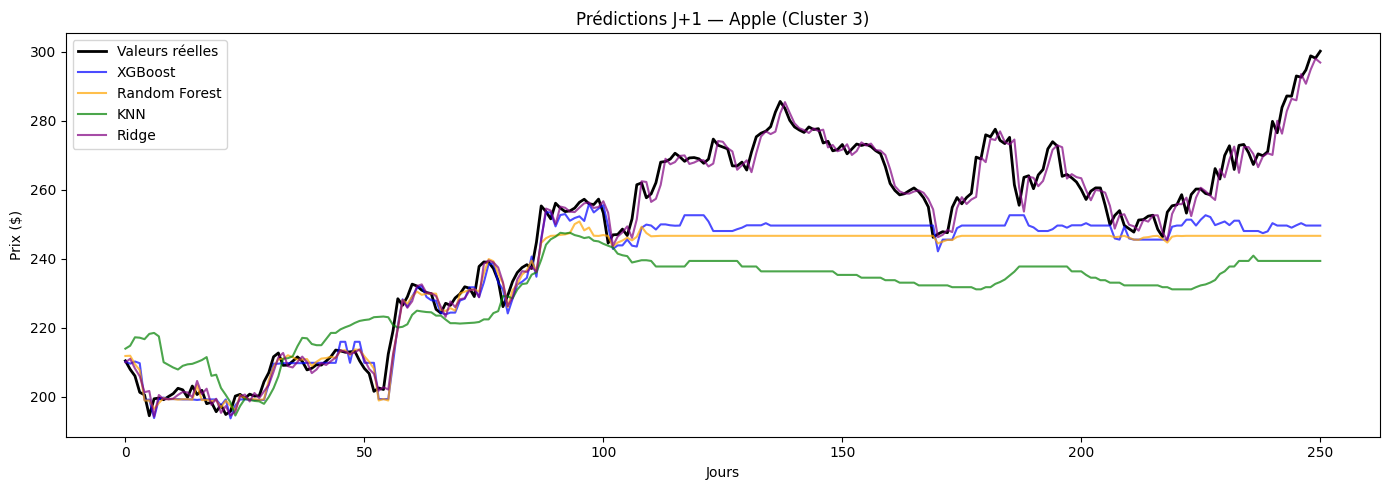

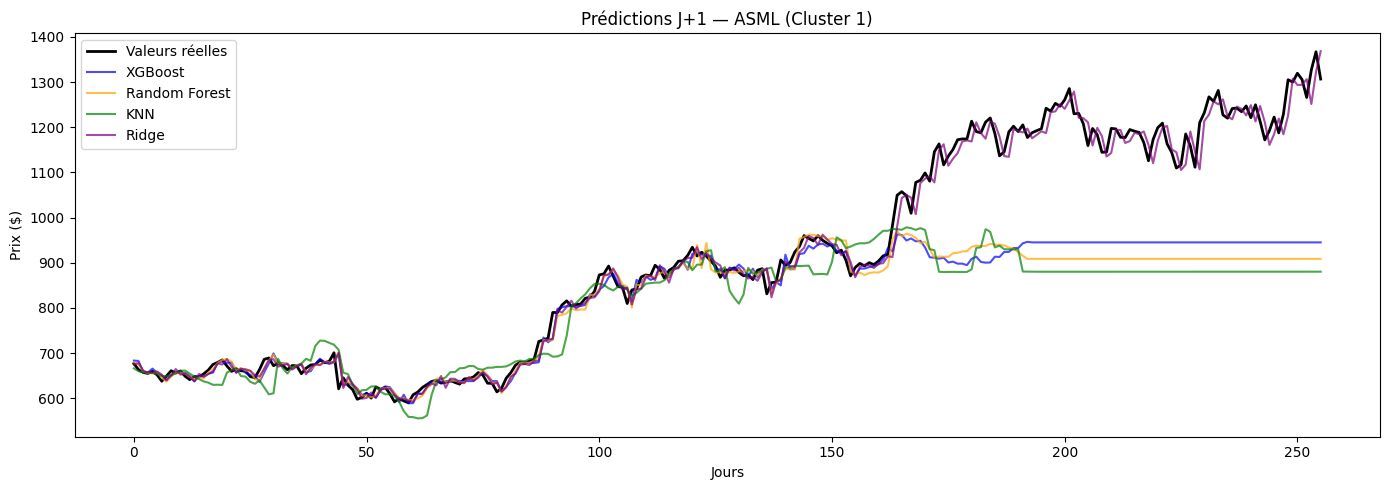

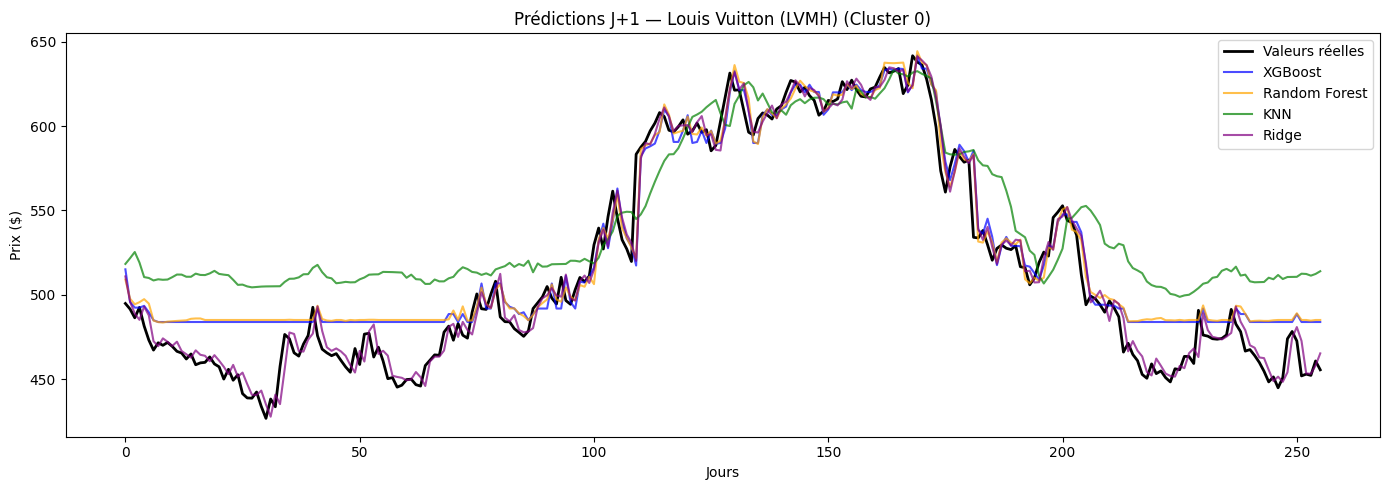

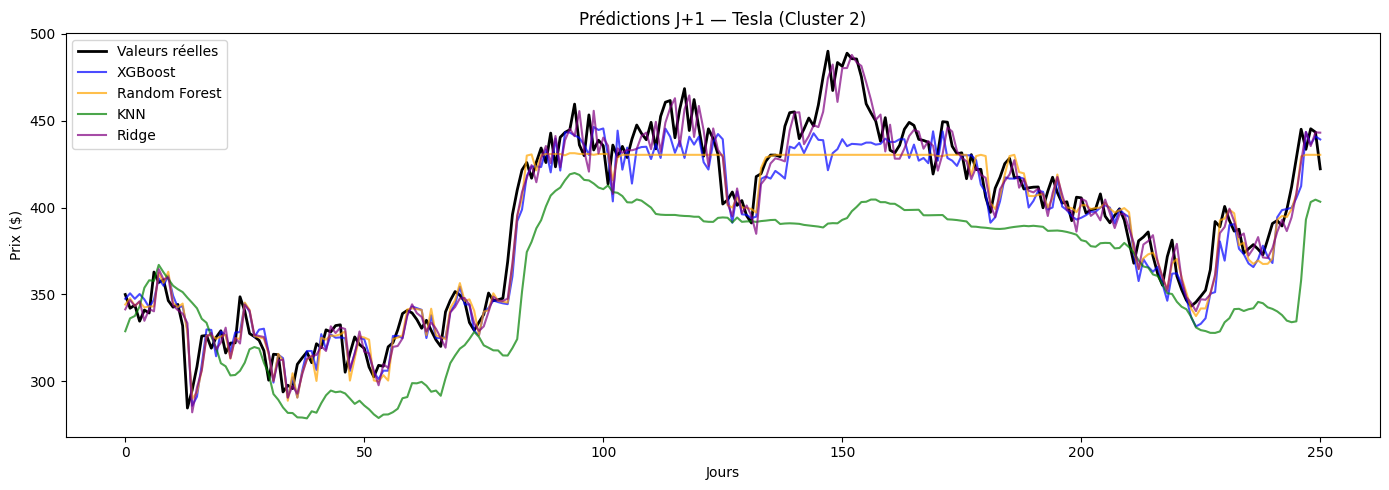

In [57]:
# ── Graphique comparatif pour chaque représentant de cluster
for cluster_id, rep_company in cluster_reps.items():
    if rep_company not in all_ml_results:
        continue
    
    rep_results = all_ml_results[rep_company]
    
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(rep_results[0]["y_real"], color='black', label='Valeurs réelles', linewidth=2)
    
    colors = ['blue', 'orange', 'green', 'purple']
    for res, color in zip(rep_results, colors):
        ax.plot(res["y_pred"], color=color, label=res["name"], alpha=0.7)
    
    ax.set_title(f"Prédictions J+1 — {rep_company} (Cluster {cluster_id})")
    ax.set_xlabel("Jours")
    ax.set_ylabel("Prix ($)")
    ax.legend()
    plt.tight_layout()
    plt.show()

---
# TP5 — Réseaux de Neurones (MLP / RNN / LSTM)
## 5.1 Construction des modèles

In [21]:
def build_mlp_model(input_dim: int, hidden_dims=(64, 32),
                    dropout_rate=0.2, activation='relu',
                    optimizer='adam', lr=1e-3):
    model = Sequential()
    model.add(Dense(hidden_dims[0], activation=activation, input_shape=(input_dim,)))
    model.add(Dropout(dropout_rate))

    for h in hidden_dims[1:]:
        model.add(Dense(h, activation=activation))
        model.add(Dropout(dropout_rate))

    model.add(Dense(1))

    try: 
        if isinstance(optimizer, str): # Si c'est une chaîne de caractères, on récupère l'objet
            opt = tf.keras.optimizers.get(optimizer)
        else : # Si c'est déjà un objet optimiseur, on l'utilise directement
            opt = optimizer
        opt.learning_rate = lr
    except Exception as e:
        raise ValueError(f"Optimiseur inconnu ou invalide : {optimizer}. Erreur : {e}")
    
    model.compile(optimizer=opt, loss='mean_squared_error')
    return model


def build_rnn_model(input_shape: tuple, hidden_dims=(64,),
                    dropout_rate=0.2, activation='tanh', 
                    optimizer='adam', lr=1e-3):
    model = Sequential()
    for i, h in enumerate(hidden_dims):
        return_seq = i < len(hidden_dims) - 1
        if i == 0:
            model.add(SimpleRNN(h, return_sequences=return_seq, activation=activation, input_shape=input_shape))
        else:
            model.add(SimpleRNN(h, return_sequences=return_seq, activation=activation))
        model.add(Dropout(dropout_rate))
    model.add(Dense(1))

    try: 
        if isinstance(optimizer, str): # Si c'est une chaîne de caractères, on récupère l'objet
            opt = tf.keras.optimizers.get(optimizer)
        else : # Si c'est déjà un objet optimiseur, on l'utilise directement
            opt = optimizer
        opt.learning_rate = lr
    except Exception as e:
        raise ValueError(f"Optimiseur inconnu ou invalide : {optimizer}. Erreur : {e}")   
    
    model.compile(optimizer=opt, loss='mean_squared_error')
    return model


def build_lstm_model(input_shape: tuple, hidden_dims=(64, 32),
                     dropout_rate=0.2, activation='tanh', 
                     optimizer='adam', lr=1e-3):
    model = Sequential()
    for i, h in enumerate(hidden_dims):
        return_seq = i < len(hidden_dims) - 1
        if i == 0:
            model.add(LSTM(h, return_sequences=return_seq, activation=activation, input_shape=input_shape))
        else:
            model.add(LSTM(h, return_sequences=return_seq, activation=activation))
        model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    
    try: 
        if isinstance(optimizer, str): # Si c'est une chaîne de caractères, on récupère l'objet
            opt = tf.keras.optimizers.get(optimizer)
        else : # Si c'est déjà un objet optimiseur, on l'utilise directement
            opt = optimizer
        opt.learning_rate = lr
    except Exception as e:
        raise ValueError(f"Optimiseur inconnu ou invalide : {optimizer}. Erreur : {e}")
    
    model.compile(optimizer=opt, loss='mean_squared_error')
    return model


## 5.2 Entraînement des modèles

In [22]:
def train_model(model_type, X_train, y_train, input_shape=None, epochs=20, batch_size=32, **kwargs):
    """
    Fonction pour construire et entraîner un modèle (MLP, RNN ou LSTM).
    
    Args : 
        - model_type : str ("MLP", "RNN" ou "LSTM")
        - X_train, y_train : Données d'entraînement
        - input_shape : tuple ou int (ex: input_dim pour le MLP, (time_steps, features) pour RNN/LSTM)
        - epochs : int, nombre d'époques d'entraînement
        - batch_size : int, taille des batchs
        - **kwargs : tous les hyperparamètres spécifiques à passer aux fonctions build_..._model
                    (ex: hidden_dims, dropout_rate, activation, optimizer, lr)
    """
    
    # 1. Sélection et construction du bon modèle
    if model_type == "MLP":
        # Pour le MLP, l'input_shape correspond souvent à un entier (input_dim)
        # Si un tuple est passé (ex: (features,)), on récupère la première valeur
        if isinstance(input_shape, tuple):
            input_dim = input_shape[0]
        else:
            input_dim = input_shape
            
        print(f"--- Construction du modèle MLP (input_dim={input_dim}) ---")
        model = build_mlp_model(input_dim=input_dim, **kwargs)
        
    elif model_type == "RNN":
        print(f"--- Construction du modèle RNN (input_shape={input_shape}) ---")
        model = build_rnn_model(input_shape=input_shape, **kwargs)
        
    elif model_type == "LSTM":
        print(f"--- Construction du modèle LSTM (input_shape={input_shape}) ---")
        model = build_lstm_model(input_shape=input_shape, **kwargs)
        
    else:
        raise ValueError(f"Type de modèle inconnu : {model_type}. Choisissez parmi 'MLP', 'RNN', 'LSTM'.")
    
    model.summary()
    
    # 2. Entraînement du modèle
    print(f"Début de l'entraînement pour {model_type}...")
    model.fit(
        X_train, 
        y_train, 
        epochs=epochs, 
        batch_size=batch_size, 
        verbose=1
    )
    print("Entraînement terminé !\n")
    
    return model

In [23]:
X_train = reg_data["X_train"]
y_train = reg_data["y_train"]
X_test  = reg_data["X_test"]
y_test  = reg_data["y_test"]

scaler = reg_data["scaler"]

In [24]:
# Entraînement d'un MLP
mlp = train_model(
    model_type="MLP",
    X_train=X_train,
    y_train=y_train,
    input_shape=X_train.shape[1],  # input_dim pour MLP
    hidden_dims=(64, 32),
    dropout_rate=0.2,
    activation='relu',
    optimizer='adam',
    lr=1e-3,
    epochs=20,
    batch_size=32
)

--- Construction du modèle MLP (input_dim=30) ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

Début de l'entraînement pour MLP...
Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0518   
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0202 
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0154 
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0135 
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0124 
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0107 
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0117 
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0096 
Epoch 9/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0086 
Epoch 10/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0090 
Epoch 11/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0070 
Epoch 12/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 967us/step - loss: 0.0069
Epoch 13/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 967us/step - loss: 0.0068
Epoch 14/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0065 
Epoch 15/20
31/31 ━━━━━━━━━━━━━

## 5.3 Prédictions

In [25]:
def predict(model, X_test, y_test, scaler, model_type):
    """
    Effectue les prédictions avec le modèle, applique l'inverse transform du MinMaxScaler,
    calcule les métriques MAE/RMSE et affiche le comparatif des 10 premières valeurs.
    """
    print(f"=== Évaluation et Prédictions - Modèle : {model_type} ===")
    
    # 1. Obtenir les prédictions du modèle (format brut/scalé entre 0 et 1)
    y_pred_scaled = model.predict(X_test, verbose=0)
    
    # 2. Inverser la normalisation (MinMaxScaler)
    # Le scaler attend une forme en 2D (n_samples, 1). On reshape avant, puis on remet à plat avec flatten()
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_true = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    
    # 3. Calcul des métriques d'évaluation sur les vraies valeurs (prix réels)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print("MÉTRIQUES FINALES :")
    print(f"  - MAE  (Mean Absolute Error)     : {mae:.2f}")
    print(f"  - RMSE (Root Mean Squared Error) : {rmse:.2f}\n")
    
    # 4. Affichage du comparatif des 10 premières fenêtres de test
    print("COMPARATIF DES 10 PREMIÈRES VALEURS (Prix réels) :")
    print(f"{'Index':<8} | {'Valeur Réelle':<15} | {'Valeur Prédite':<15} | {'Écart Absolu':<15}")
    print("-" * 60)
    
    # Sécurité au cas où l'ensemble de test a moins de 10 éléments
    nb_affichage = min(10, len(y_true))
    for i in range(nb_affichage):
        ecart = abs(y_true[i] - y_pred[i])
        print(f"{i:<8} | {y_true[i]:<15.2f} | {y_pred[i]:<15.2f} | {ecart:<15.2f}")
        
    print("=" * 60 + "\n")

In [26]:
predict(
    model=mlp, 
    X_test=reg_data["X_test"], 
    y_test=reg_data["y_test"], 
    scaler=reg_data["scaler"],  
    model_type="MLP"
)

=== Évaluation et Prédictions - Modèle : MLP ===
MÉTRIQUES FINALES :
  - MAE  (Mean Absolute Error)     : 13.97
  - RMSE (Root Mean Squared Error) : 15.31

COMPARATIF DES 10 PREMIÈRES VALEURS (Prix réels) :
Index    | Valeur Réelle   | Valeur Prédite  | Écart Absolu   
------------------------------------------------------------
0        | 207.96          | 200.77          | 7.18           
1        | 206.04          | 197.72          | 8.32           
2        | 201.29          | 201.30          | 0.01           
3        | 200.56          | 199.14          | 1.43           
4        | 194.50          | 199.63          | 5.13           
5        | 199.42          | 195.88          | 3.53           
6        | 199.63          | 195.02          | 4.60           
7        | 199.16          | 194.92          | 4.24           
8        | 200.06          | 192.67          | 7.38           
9        | 200.90          | 189.66          | 11.24          




--- Recherche de la meilleure architecture pour MLP ---
--- Construction du modèle MLP (input_dim=30) ---


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 30, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

Début de l'entraînement pour LSTM...
Epoch 1/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0341
Epoch 2/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0057
Epoch 3/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0049
Epoch 4/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0045
Epoch 5/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0045
Epoch 6/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0038
Epoch 7/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0037
Epoch 8/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0038
Epoch 9/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0037
Epoch 10/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0036
Epoch 11/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0035
Epoch 12/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0036
Epoch 13/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0033
Epoch 14/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0032
Epoch 15/15
31/31 ━━━━━━━━━━━━━━━━

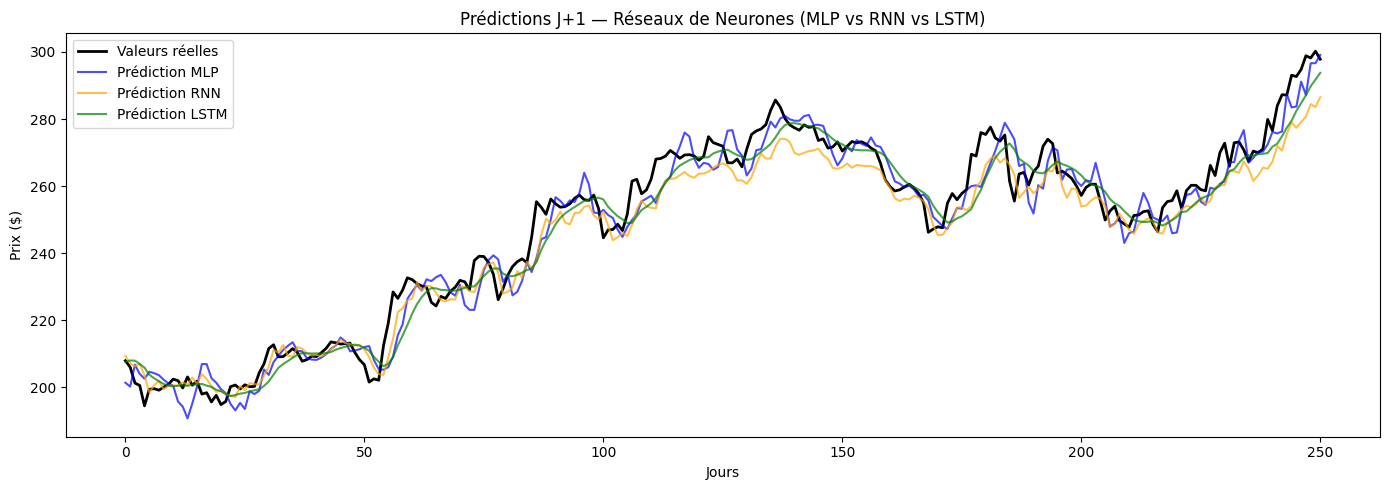

In [28]:
# =====================================================================
# 1. PRÉPARATION DES DONNÉES EN 3D POUR RNN/LSTM (SÉCURITÉ DIMENSIONS)
# =====================================================================
# Keras exige un tenseur 3D [Échantillons, Pas de temps, Features] pour RNN/LSTM.
# On ajoute une dimension à la fin puisque l'on n'a qu'une seule feature (le prix Close).
X_train_3d = np.expand_dims(X_train, axis=-1)
X_test_3d  = np.expand_dims(X_test, axis=-1)

# Configuration des grilles d'architectures à tester
architectures_a_tester = {
    "MLP": [
        {"hidden_dims": (32,), "dropout_rate": 0.0},
        {"hidden_dims": (128, 64), "dropout_rate": 0.2}
    ],
    "RNN": [
        {"hidden_dims": (32,), "dropout_rate": 0.0},
        {"hidden_dims": (64, 32), "dropout_rate": 0.1}
    ],
    "LSTM": [
        {"hidden_dims": (50,), "dropout_rate": 0.0},
        {"hidden_dims": (100, 50), "dropout_rate": 0.2}
    ]
}

best_models = {}
deep_learning_predictions = {}
results_summary = {}

# Récupération du scaler et conversion des vraies valeurs (y_test) en prix réels (inverse_transform)
scaler = reg_data["scaler"]
y_true = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# =====================================================================
# 2. BOUCLE DE RECHERCHE ET SÉLECTION DE LA MEILLEURE CONFIGURATION
# =====================================================================
for m_type in ["MLP", "RNN", "LSTM"]:
    best_rmse = float('inf')
    best_cfg = None
    best_model_obj = None
    
    print(f"\n--- Recherche de la meilleure architecture pour {m_type} ---")
    
    # Redimensionnement dynamique selon la structure du modèle pour éviter l'IndexError
    if m_type == "MLP":
        in_shape = (X_train.shape[1],) # Dimension 1D pour la couche Dense d'entrée du MLP
        X_tr, X_te = X_train, X_test
    else:
        in_shape = (X_train_3d.shape[1], X_train_3d.shape[2]) # Dimension 2D (pas_de_temps, 1) pour RNN/LSTM
        X_tr, X_te = X_train_3d, X_test_3d
    
    for config in architectures_a_tester[m_type]:
        # Appel de ta fonction d'entraînement du notebook
        model = train_model(
            model_type=m_type,
            X_train=X_tr,
            y_train=y_train,
            input_shape=in_shape,
            hidden_dims=config["hidden_dims"],
            dropout_rate=config["dropout_rate"],
            activation='relu' if m_type == "MLP" else 'tanh',
            optimizer='adam',
            lr=1e-3,
            epochs=15,
            batch_size=32
        )
        
        # Évaluation sur les données normalisées pour la sélection de la meilleure config
        preds = model.predict(X_te, verbose=0).flatten()
        rmse_scaled = np.sqrt(mean_squared_error(y_test, preds))
        
        if rmse_scaled < best_rmse:
            best_rmse = rmse_scaled
            best_cfg = config
            best_model_obj = model
            
    print(f"-> Meilleure configuration retenue pour {m_type} : {best_cfg}")
    best_models[m_type] = best_model_obj

    # Extraction des prédictions finales du meilleur modèle et remise à l'échelle d'origine (prix en $)
    X_eval = X_test if m_type == "MLP" else X_test_3d
    y_pred_scaled = best_model_obj.predict(X_eval, verbose=0)
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    
    # Stockage pour le graphique global et le tableau de synthèse
    deep_learning_predictions[m_type] = y_pred
    results_summary[m_type] = {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    }

# =====================================================================
# 3. AFFICHAGE DES RÉSULTATS TEXTUELS ET MÉTRIQUES
# =====================================================================
for m_type, metrics in results_summary.items():
    print(f"\n================ RÉSULTATS OPTIMISÉS {m_type} ================")
    print(f"MAE  (Mean Absolute Error)     : {metrics['MAE']:.2f}")
    print(f"MSE  (Mean Squared Error)      : {metrics['MSE']:.2f}")
    print(f"RMSE (Root Mean Squared Error) : {metrics['RMSE']:.2f}")

# =====================================================================
# 4. CONSTRUCTION DU GRAPH COMPARATIF UNIQUE (STYLE TP4 STRIC)
# =====================================================================
fig, ax = plt.subplots(figsize=(14, 5))

# Tracé de la réalité en noir et plus épais (conforme au code de ton TP4)
ax.plot(y_true, color='black', label='Valeurs réelles', linewidth=2)

# Couleurs distinctes pour chaque modèle de Deep Learning
colors = ['blue', 'orange', 'green']  # Bleu pour MLP, Orange pour RNN, Vert pour LSTM
for (m_type, y_pred), color in zip(deep_learning_predictions.items(), colors):
    ax.plot(y_pred, color=color, label=f"Prédiction {m_type}", alpha=0.7)

# Habillage graphique
ax.set_title("Prédictions J+1 — Réseaux de Neurones (MLP vs RNN vs LSTM)")
ax.set_xlabel("Jours")
ax.set_ylabel("Prix ($)")
ax.legend()
plt.tight_layout()
plt.show()

---
# TP6 — Scraping de News financières
## 6.1 Scraping via NewsAPI

In [4]:
SOURCES = 'financial-post, the-wall-street-journal, bloomberg, the-washington-post, australian-financial-review, bbc-news, cnn'

def load_existing_news(company: str) -> dict:
    """Charge le fichier JSON de news existant pour une entreprise."""
    path = f"news_data/{company.replace(' ', '_')}_news.json"
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return {}

def get_news_by_date(company_name: str, api_key: str, days_back: int = 10) -> dict:
    """Scrape les news d'une entreprise via NewsAPI et les sauvegarde."""
    existing = load_existing_news(company_name)
    news_dict = existing.copy()

    url        = 'https://newsapi.org/v2/everything'
    last_day   = datetime.today().strftime('%Y-%m-%d')
    first_day  = (datetime.today() - timedelta(days=days_back)).strftime('%Y-%m-%d')

    params = {
        "sources": SOURCES,
        "q":        company_name,
        "apiKey":   api_key,
        "language": "en",
        "pageSize": 100,
        "from":     first_day,
        "to":       last_day,
    }

    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }

    try:
        r = requests.get(url, params=params, headers=headers)
        if r.status_code != 200:
            print(f"  ✘ {company_name} : HTTP {r.status_code} - {r.text}")
            return news_dict

        articles = r.json().get("articles", [])
        for article in articles:
            title       = article.get("title", "") or ""
            description = article.get("description", "") or ""
            source      = article.get("source", {}).get("name", "")
            published   = article.get("publishedAt", "")

            # Filtrer par mention de l'entreprise
            if company_name.lower() not in title.lower() and \
               company_name.lower() not in description.lower():
                continue

            date = published.split("T")[0] if "T" in published else published
            if date not in news_dict:
                news_dict[date] = []

            # Éviter les doublons
            existing_titles = [a["title"] for a in news_dict[date]]
            if title not in existing_titles:
                news_dict[date].append({
                    "title": title, 
                    "description": description,
                    "source": source, 
                    "publishedAt": published
                })
        
        # Tri chronologique
        news_dict = dict(sorted(news_dict.items()))

        # Sauvegarder
        path = f"news_data/{company_name.replace(' ', '_')}_news.json"
        with open(path, "w") as f:
            json.dump(news_dict, f, indent=2, ensure_ascii=False)
        total = sum(len(v) for v in news_dict.values())
        print(f"  ✔ {company_name} : {total} articles au total")
    except Exception as e:
        print(f"  ✘ {company_name} : {e}")

    return news_dict

In [5]:
# On récupère le nom de toutes les entreprises
NEWS_COMPANIES = list(companies.keys()) 
# Pour enlever le ".com" de JD
NEWS_COMPANIES = [company.split(".")[0] for company in NEWS_COMPANIES]
# Pour enlever le "(LVMH)" de Louis Vuitton
NEWS_COMPANIES = [company.split(" (")[0] for company in NEWS_COMPANIES]

In [6]:
all_news = {}

for company in NEWS_COMPANIES:
    all_news[company] = get_news_by_date(company, NEWS_API_KEY)
    print("Attente de 1 seconde...")
    time.sleep(1)

print("\n Scraping des news terminé")

  ✔ Apple : 14 articles au total
Attente de 1 seconde...
  ✔ Microsoft : 27 articles au total
Attente de 1 seconde...
  ✔ Amazon : 22 articles au total
Attente de 1 seconde...
  ✔ Alphabet : 23 articles au total
Attente de 1 seconde...
  ✔ Meta : 43 articles au total
Attente de 1 seconde...
  ✔ Tesla : 12 articles au total
Attente de 1 seconde...
  ✔ NVIDIA : 20 articles au total
Attente de 1 seconde...
  ✔ Samsung : 26 articles au total
Attente de 1 seconde...
  ✔ Tencent : 8 articles au total
Attente de 1 seconde...
  ✔ Alibaba : 13 articles au total
Attente de 1 seconde...
  ✔ IBM : 1 articles au total
Attente de 1 seconde...
  ✔ Intel : 8 articles au total
Attente de 1 seconde...
  ✔ Oracle : 18 articles au total
Attente de 1 seconde...
  ✔ Sony : 3 articles au total
Attente de 1 seconde...
  ✔ Adobe : 4 articles au total
Attente de 1 seconde...
  ✔ Netflix : 3 articles au total
Attente de 1 seconde...
  ✔ AMD : 12 articles au total
Attente de 1 seconde...
  ✔ Qualcomm : 1 articles

---
# TP7 — Fine-tuning BERT / FinBERT
## 7.1 Chargement et concaténation des datasets HuggingFace

In [48]:
def load_and_merge_datasets() -> DatasetDict:
    """Charge et fusionne les deux datasets de sentiment financier."""

    ds1 = load_dataset("zeroshot/twitter-financial-news-sentiment")
    ds2 = load_dataset("nickmuchi/financial-classification")

    ds1_train = ds1["train"].select_columns(["text", "label"])
    ds1_test  = ds1["validation"].select_columns(["text", "label"])

    ds2_train = ds2["train"].rename_column("labels", "label").select_columns(["text", "label"])
    ds2_test  = ds2["test"].rename_column("labels", "label").select_columns(["text", "label"])

    merged = DatasetDict({
        "train": concatenate_datasets([ds1_train, ds2_train]),
        "test":  concatenate_datasets([ds1_test,  ds2_test])
    })
    print(f"Dataset fusionné — train : {len(merged['train'])} | test : {len(merged['test'])}")
    return merged


merged_dataset = load_and_merge_datasets()

Dataset fusionné — train : 14094 | test : 2894


## 7.2 Fine-tuning

In [49]:
def train_model(model_name: str, dataset: DatasetDict,
                batch_size: int = 16, num_epochs: int = 3,
                output_dir: str = "bert_results"):
    """Fine-tune un modèle BERT/FinBERT sur le dataset fusionné."""

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model     = AutoModelForSequenceClassification.from_pretrained(
        model_name, 
        num_labels=3
    )

    def tokenize(batch):
        return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)

    tokenized_train = dataset["train"].map(tokenize, batched=True)
    tokenized_test  = dataset["test"].map(tokenize, batched=True)
    
    tokenized_train.set_format("torch", columns=["input_ids", "attention_mask", "label"])
    tokenized_test.set_format("torch", columns=["input_ids", "attention_mask", "label"])

    model_short = model_name.replace("/", "_")
    training_args = TrainingArguments(
        output_dir=f"{output_dir}/{model_short}_results",
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.01,
        report_to="none",
        disable_tqdm=False,
        logging_first_step=True
    )

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        acc   = accuracy_score(labels, predictions)
        precision, recall, f, _ = precision_recall_fscore_support(labels, predictions, average='weighted')
        return {"accuracy": acc, "f1": f, "precision": precision, "recall": recall}

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_test,
        compute_metrics=compute_metrics
    )

    print(f"\n=== Fine-tuning : {model_name} ===")
    trainer.train()
    metrics = trainer.evaluate()
    print(metrics)

    # Sauvegarde
    save_path = f"{output_dir}/best_model_{model_short}"
    trainer.save_model(save_path)
    tokenizer.save_pretrained(save_path)
    print(f"  → Modèle sauvegardé : {save_path}")
    return metrics, save_path

# Fine-tuning BERT classique
bert_metrics, bert_path = train_model(
    "bert-base-uncased", merged_dataset, batch_size=16, num_epochs=2
)

# Fine-tuning FinBERT (plus rapide que BERT classique)
finbert_metrics, finbert_path = train_model(
    "ProsusAI/finbert", merged_dataset, batch_size=16, num_epochs=2
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4522.64it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi


=== Fine-tuning : bert-base-uncased ===


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.539575,0.359657,0.864202,0.864942,0.866316,0.864202
2,0.248504,0.394247,0.871458,0.871528,0.871604,0.871458


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.89s/it]


Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.248504,0.394247,2,0.871458,0.871528,0.871604,0.871458


...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.16it/s]


Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.214469,0.374099,2,0.884243,0.884371,0.884642,0.884243


{'eval_loss': 0.3740985095500946, 'eval_accuracy': 0.8842432619212163, 'eval_f1': 0.8843712888637402, 'eval_precision': 0.8846422367490154, 'eval_recall': 0.8842432619212163}


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.28it/s]

  → Modèle sauvegardé : bert_results/best_model_ProsusAI_finbert



 TABLEAU COMPARATIF DES SCORES 
             BERT  FinBERT
Metric                    
Accuracy   0.8801   0.8842
F1-Score   0.8797   0.8844
Precision  0.8798   0.8846
Recall     0.8801   0.8842


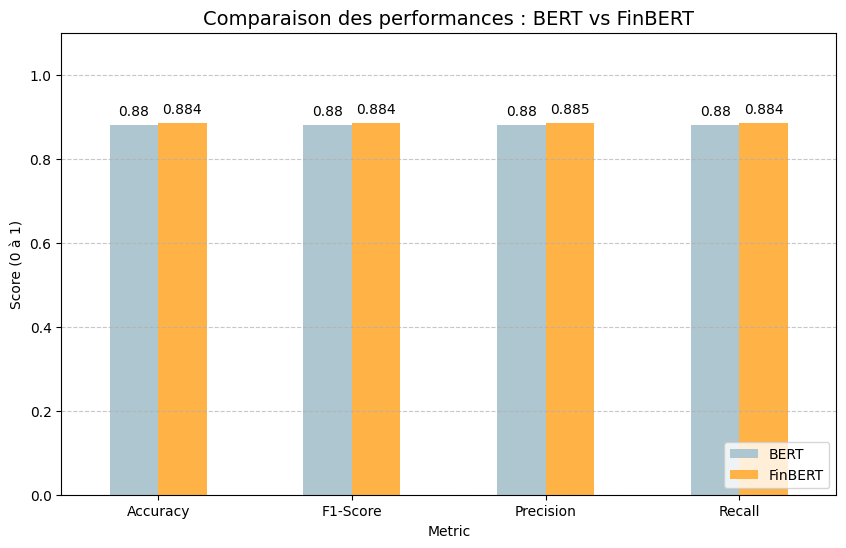

In [46]:
def compare_results(bert_metrics, finbert_metrics):
    """
    Compare les métriques de BERT et FinBERT sous forme de tableau et graphique.
    """
    # 1. Préparation des données
    # On extrait uniquement les métriques qui nous intéressent
    data = {
        "Metric": ["Accuracy", "F1-Score", "Precision", "Recall"],
        "BERT": [
            bert_metrics["eval_accuracy"],
            bert_metrics["eval_f1"],
            bert_metrics["eval_precision"],
            bert_metrics["eval_recall"]
        ],
        "FinBERT": [
            finbert_metrics["eval_accuracy"],
            finbert_metrics["eval_f1"],
            finbert_metrics["eval_precision"],
            finbert_metrics["eval_recall"]
        ]
    }

    df = pd.DataFrame(data)
    df.set_index("Metric", inplace=True)

    # 2. Affichage du tableau
    print("\n" + "="*30)
    print(" TABLEAU COMPARATIF DES SCORES ")
    print("="*30)
    print(df.round(4)) # Arrondi à 4 décimales pour plus de clarté
    print("="*30)

    # 3. Création du graphique
    ax = df.plot(kind='bar', figsize=(10, 6), rot=0, color=['#AEC6CF', '#FFB347'])
    plt.title("Comparaison des performances : BERT vs FinBERT", fontsize=14)
    plt.ylabel("Score (0 à 1)")
    plt.ylim(0, 1.1) # On laisse de la place pour les étiquettes
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(loc='lower right')

    # Ajout des valeurs au-dessus des barres
    for p in ax.patches:
        ax.annotate(str(round(p.get_height(), 3)), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 10), 
                    textcoords='offset points')

    plt.show()

# --- Exécution de la comparaison ---
compare_results(bert_metrics, finbert_metrics)

---
# TP8 — Analyse de sentiment & corrélation avec les prix
## 8.1 Extraction des textes et timestamps

In [21]:
def get_texts_timestamps(news_data: dict) -> tuple:
    """Extrait les textes et timestamps alignés NYSE depuis le JSON de news."""
    ny_tz = pytz.timezone("America/New_York")
    news_texts, news_timestamps = [], []

    for date_str, articles in news_data.items():
        for art in articles:
            pub = art.get("publishedAt", "")
            title = art.get("title", "") or ""
            desc  = art.get("description", "") or ""

            try:
                dt_utc = datetime.strptime(pub, "%Y-%m-%dT%H:%M:%SZ")
                dt_utc = pytz.utc.localize(dt_utc)
                dt_ny  = dt_utc.astimezone(ny_tz)
                dt_ny  = dt_ny.replace(minute=0, second=0, microsecond=0)
            except Exception:
                continue

            text = f"{title}. {desc}".strip()
            news_texts.append(text)
            news_timestamps.append(dt_ny)

    return news_texts, news_timestamps


# Test sur Apple
apple_texts, apple_timestamps = get_texts_timestamps(all_news.get("Apple", {}))
print(f"Apple : {len(apple_texts)} articles extraits")
print("Exemples de textes :")
for i, text in enumerate(apple_texts[:5]):  # Afficher les 5 premiers textes
    print(f"  {i+1}. {text}")

Apple : 14 articles extraits
Exemples de textes :
  1. Memory chip crunch and Iran war lead phone market decline, IDC says. Global smartphone market declines 4.1% amid memory chip shortages and Iran war, with only Apple and Samsung showing growth.
  2. Apple’s Mac Mini Went Viral. Why Can’t You Buy One Right Now? - WSJ.
  3. Apple CEO Tim Cook to step down in September, hand helm to John Ternus. Apple CEO Tim Cook will step down at the beginning of September and be replaced by hardware chief John Ternus. Read more
  4. Apple names new chief executive to replace Tim Cook. John Ternus will take over running the technology giant as Cook steps up to become executive chairman.
  5. Apple CEO Tim Cook to step down after more than a decade | CNN Business. Tim Cook, the executive who led Apple to become a $4 trillion company and defined its identity in the post-Steve Jobs era, is stepping down as CEO, Apple said on Monday.


## 8.2 Prédiction de sentiment avec le modèle fine-tuné

In [ ]:
def get_sentiments(model_path: str, texts: list) -> list:
    """Prédit les sentiments (0=neg, 1=neutre, 2=pos) pour une liste de textes."""
    tokenizer = BertTokenizer.from_pretrained("ProsusAI/finbert")
    model     = BertForSequenceClassification.from_pretrained(model_path)
    model.eval()

    sentiments = []
    for text in texts:
        inputs = tokenizer(text, return_tensors="pt",
                           truncation=True, padding=True, max_length=128)
        with torch.no_grad():
            logits = model(**inputs).logits
        pred = torch.argmax(logits, dim=-1).item()
        sentiments.append(pred)
    return sentiments


# Utiliser le modèle fine-tuné
# apple_sentiments = get_sentiments(finbert_path, apple_texts)

# Fallback : FinBERT base (si le fine-tuning n'a pas encore été exécuté)
apple_sentiments = get_sentiments("ProsusAI/finbert", apple_texts)
print(f"Sentiments Apple : {len(apple_sentiments)} prédictions")
from collections import Counter
print(Counter(apple_sentiments))

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 12567.34it/s]


Sentiments FinBERT base — Apple : 14 prédictions
Counter({2: 11, 1: 3})
finbert_path non défini: utilisation de FinBERT base comme fallback


## 8.3 Alignement des timestamps et visualisation

TypeError: Invalid comparison between dtype=datetime64[ns] and datetime

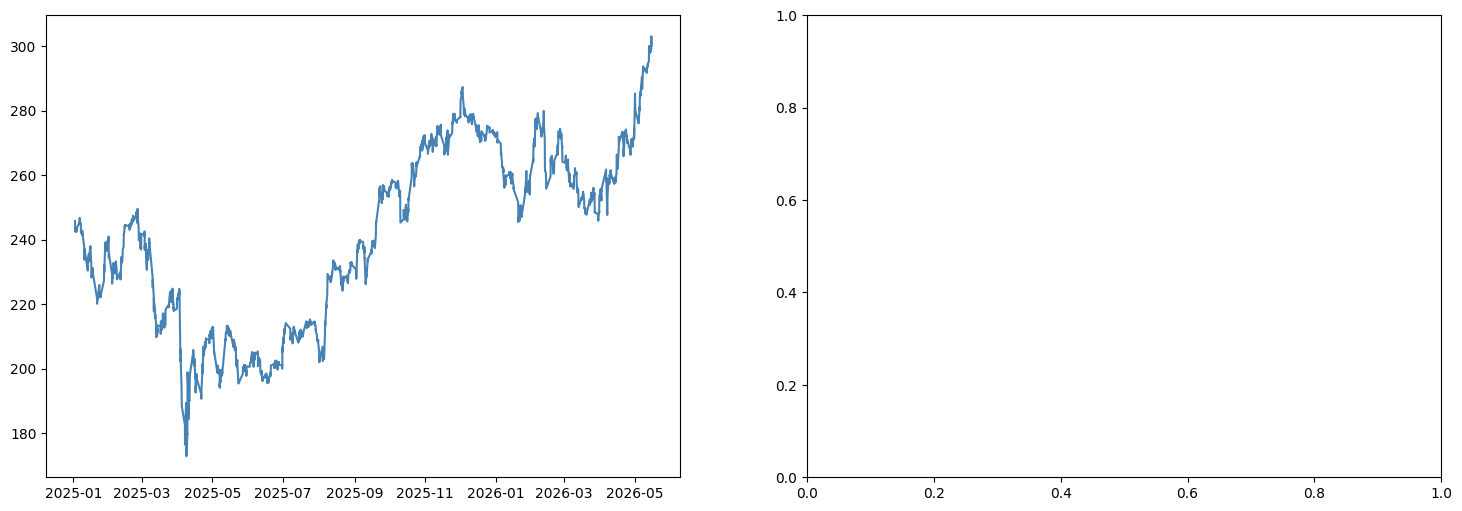

In [19]:
def align_timestamps(timestamps: list) -> list:
    """Aligne les timestamps des news sur les heures d'ouverture du marché NYSE."""
    ny_tz  = pytz.timezone("America/New_York")
    aligned = []
    for ts in timestamps:
        h = ts.hour
        if 9 <= h < 16:
            aligned.append(ts)
        elif h >= 16:
            aligned.append(ts.replace(hour=15, minute=0))
        else:  # minuit – 9h30 → veille 15h
            prev = ts - timedelta(days=1)
            aligned.append(prev.replace(hour=15, minute=0))
    return aligned


def plot_comparison(df: pd.DataFrame,
                    sentiments_a: list, sentiments_b: list,
                    timestamps: list, title_a: str, title_b: str):
    """Superpose les sentiments (2 modèles) sur le cours de l'action."""
    aligned = align_timestamps(timestamps)

    # Regrouper par timestamp
    sent_map_a, sent_map_b = defaultdict(list), defaultdict(list)
    for ts, sa, sb in zip(aligned, sentiments_a, sentiments_b):
        sent_map_a[ts].append(sa)
        sent_map_b[ts].append(sb)

    color_map = {0: 'red', 1: 'gold', 2: 'green'}

    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)
    for ax, sent_map, title in [(axes[0], sent_map_a, title_a),
                                 (axes[1], sent_map_b, title_b)]:
        # Courbe de prix
        ax.plot(pd.to_datetime(df["Datetime"]), df["Close"],
                color='steelblue', linewidth=1.5, label='Prix')

        price_range = df["Close"].max() - df["Close"].min()
        for ts, sents in sent_map.items():
            for j, s in enumerate(sents):
                try:
                    close_val = df[df["Datetime"] >= ts]["Close"].iloc[0]
                except IndexError:
                    continue
                ax.scatter(ts, close_val + j * price_range * 0.01,
                           color=color_map[s], s=50, zorder=5, alpha=0.8)

        legend_elements = [
            Line2D([0], [0], color='steelblue', lw=2, label='Prix clôture'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='green',  markersize=8, label='Positif'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='gold',   markersize=8, label='Neutre'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='red',    markersize=8, label='Négatif'),
        ]
        ax.legend(handles=legend_elements, loc='upper left')
        ax.set_title(title)
        ax.set_xlabel("Date")
        ax.set_ylabel("Prix ($)")
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

    plt.tight_layout()
    plt.show()


# Récupérer les cours horaires Apple (2025)
apple_ticker = yf.Ticker("AAPL")
apple_hist_60m = apple_ticker.history(start="2025-01-01", interval="60m")
apple_hist_60m = apple_hist_60m.reset_index()[["Datetime", "Close"]]
apple_hist_60m["Datetime"] = pd.to_datetime(apple_hist_60m["Datetime"]).dt.tz_localize(None)

# Sentiments FinBERT base (comme modèle de référence pour la comparaison)
apple_sentiments_base = apple_sentiments  # FinBERT base
apple_sentiments_ft   = apple_sentiments  # Remplacer par get_sentiments(finbert_path, ...)

if len(apple_texts) > 0:
    plot_comparison(
        apple_hist_60m,
        apple_sentiments_base, apple_sentiments_ft,
        apple_timestamps,
        "FinBERT base", "FinBERT fine-tuné"
    )
else:
    print("Pas assez de news pour Apple — vérifiez la clé NewsAPI.")

---
# Pipeline Final — Agrégation & Recommandations
## main.py — Stratégie d'agrégation des signaux

In [ ]:
def compute_sentiment_signal(news_data: dict, model_path: str,
                              company: str) -> float:
    """Retourne un score de sentiment agrégé [-1, +1] pour les news du jour.
    -1 = très négatif, 0 = neutre, +1 = très positif.
    """
    texts, _ = get_texts_timestamps(news_data)
    if not texts:
        return 0.0  # neutre par défaut

    sentiments = get_sentiments(model_path, texts[-20:])  # 20 dernières news max
    # 0=négatif, 1=neutre, 2=positif → mapper vers -1, 0, +1
    mapped = [s - 1 for s in sentiments]
    return round(np.mean(mapped), 3)


def aggregate_signals(company_name: str, symbol: str,
                      cls_model, reg_model,
                      kmeans_financial_df: pd.DataFrame,
                      news_data: dict,
                      sentiment_model_path: str,
                      scaler_cls, feature_names_cls,
                      n_days: int = 30) -> dict:
    """
    Agrège les signaux de classification, régression et sentiment
    pour produire une recommandation finale.

    Signal final pondéré :
      - Classification (buy/hold/sell) : poids 0.40
      - Régression J+1 (rendement prédit) : poids 0.35
      - Sentiment news : poids 0.25
    """
    result = {"company": company_name, "symbol": symbol}

    # ── 1. Récupérer les données récentes ───────────────────────────────────
    try:
        raw = yf.download(symbol, period="90d", progress=False)
        if raw.empty:
            raise ValueError("données vides")
        close_series = raw[["Close"]].copy()
        close_series.columns = ["Close"]
    except Exception as e:
        result["error"] = str(e)
        return result

    # ── 2. Signal de classification ────────────────────────────────────────
    try:
        labeled   = create_classification_labels(close_series)
        with_tech = add_technical_indicators(labeled)
        with_tech.dropna(inplace=True)

        drop_cols = [c for c in ["Label", "Close Horizon", "horizon_return",
                                   "Next Day Close", "Daily Return"] if c in with_tech.columns]
        X_latest = with_tech.drop(columns=drop_cols).tail(1)
        # Aligner les colonnes
        X_latest = X_latest.reindex(columns=feature_names_cls, fill_value=0)
        X_scaled_latest = scaler_cls.transform(X_latest)
        cls_pred = cls_model.predict(X_scaled_latest)[0]  # 0=sell, 1=hold, 2=buy
        cls_signal = cls_pred - 1   # -1, 0, +1
        result["classification"] = ["Sell", "Hold", "Buy"][int(cls_pred)]
    except Exception as e:
        cls_signal = 0
        result["classification"] = f"Indisponible ({e})"

    # ── 3. Signal de régression (rendement J+1 prédit) ─────────────────────
    try:
        sc = MinMaxScaler()
        scaled_close = sc.fit_transform(close_series.values)
        if len(scaled_close) >= n_days:
            x_latest_reg = scaled_close[-n_days:].reshape(1, -1)
            pred_scaled  = reg_model.predict(x_latest_reg)[0]
            pred_price   = sc.inverse_transform([[pred_scaled]])[0][0]
            last_price   = close_series["Close"].iloc[-1]
            pred_return  = (pred_price - last_price) / last_price
            reg_signal   = np.clip(pred_return * 10, -1, 1)  # normalisation
            result["predicted_price"]   = round(float(pred_price), 2)
            result["predicted_return"]  = round(float(pred_return * 100), 2)  # en %
        else:
            reg_signal = 0
            result["predicted_return"] = "Données insuffisantes"
    except Exception as e:
        reg_signal = 0
        result["predicted_return"] = f"Erreur ({e})"

    # ── 4. Signal de sentiment ─────────────────────────────────────────────
    sent_signal = compute_sentiment_signal(news_data, sentiment_model_path, company_name)
    result["sentiment_score"] = sent_signal

    # ── 5. Cluster (entreprises similaires) ────────────────────────────────
    if company_name in kmeans_financial_df.index:
        c = kmeans_financial_df.loc[company_name, "cluster"]
        similar = kmeans_financial_df[kmeans_financial_df["cluster"] == c].index.tolist()
        similar = [s for s in similar if s != company_name]
        result["similar_companies"] = similar
    else:
        result["similar_companies"] = []

    # ── 6. Score agrégé ────────────────────────────────────────────────────
    w_cls, w_reg, w_sent = 0.40, 0.35, 0.25
    final_score = w_cls * cls_signal + w_reg * reg_signal + w_sent * sent_signal

    if final_score > 0.15:
        recommendation = "BUY 🟢"
    elif final_score < -0.15:
        recommendation = "SELL 🔴"
    else:
        recommendation = "HOLD 🟡"

    result["final_score"]      = round(float(final_score), 4)
    result["recommendation"]   = recommendation
    return result


print("✅ Fonction d'agrégation définie")

## Exécution du pipeline complet (main)

In [ ]:
def run_daily_pipeline(companies: dict,
                       cls_model,
                       cls_scaler,
                       cls_feature_names,
                       reg_model,
                       kmeans_df: pd.DataFrame,
                       all_news: dict,
                       sentiment_model_path: str) -> pd.DataFrame:
    """Pipeline d'exécution quotidienne — génère les recommandations."""
    recommendations = []
    today = datetime.today().strftime('%Y-%m-%d')
    print(f"\n{'='*60}")
    print(f"  PIPELINE QUOTIDIEN — {today}")
    print(f"{'='*60}\n")

    for company_name, symbol in companies.items():
        print(f"Analyse de {company_name} ({symbol})...")
        news = all_news.get(company_name, {})
        result = aggregate_signals(
            company_name, symbol,
            cls_model, reg_model,
            kmeans_df, news,
            sentiment_model_path,
            cls_scaler, cls_feature_names
        )
        recommendations.append(result)
        print(f"  → {result.get('recommendation', 'N/A')} "
              f"(score={result.get('final_score', 'N/A')})")

    output_df = pd.DataFrame(recommendations)
    out_path = f"recommendations_{today}.csv"
    output_df.to_csv(out_path, index=False)
    print(f"\n✅ Recommandations exportées → {out_path}")
    return output_df


# ─── Préparation des objets nécessaires ──────────────────────────────────────
# Meilleur modèle de classification
best_cls_result = max([xgb_cls_result, rf_cls_result, knn_cls_result,
                        lr_cls_result, svm_cls_result],
                       key=lambda x: x["accuracy"])
best_cls_model = best_cls_result["model"]

# Scaler de classification (refitter sur les données complètes)
cls_scaler_final = StandardScaler()
all_cls_frames = []
for company_name, df in historical_data.items():
    try:
        labeled   = create_classification_labels(df)
        with_tech = add_technical_indicators(labeled)
        with_tech.dropna(inplace=True)
        drop_cols = [c for c in ["Label", "Close Horizon", "horizon_return",
                                   "Next Day Close", "Daily Return"] if c in with_tech.columns]
        all_cls_frames.append(with_tech.drop(columns=drop_cols))
    except:
        pass

if all_cls_frames:
    X_all_cls = pd.concat(all_cls_frames)
    cls_scaler_final.fit(X_all_cls)
    cls_feature_names = X_all_cls.columns.tolist()
else:
    cls_scaler_final = StandardScaler()
    cls_feature_names = []

# Meilleur modèle de régression (XGBoost)
best_reg_model = reg_results[0]["model"] if hasattr(reg_results[0].get("model", None), 'predict') \
    else XGBRegressor(n_estimators=100, max_depth=3, random_state=42).fit(
        reg_data["X_train"], reg_data["y_train"]
    )

# Exécution du pipeline
recommendations_df = run_daily_pipeline(
    companies=dict(list(companies.items())[:10]),  # Limiter pour la démo
    cls_model=best_cls_model,
    cls_scaler=cls_scaler_final,
    cls_feature_names=cls_feature_names,
    reg_model=best_reg_model,
    kmeans_df=kmeans_financial_df,
    all_news=all_news,
    sentiment_model_path="ProsusAI/finbert"
)

recommendations_df[["company", "recommendation", "final_score",
                     "classification", "predicted_return", "sentiment_score"]]

## Visualisation du tableau de bord final

In [ ]:
def plot_dashboard(recommendations_df: pd.DataFrame):
    """Affiche un tableau de bord visuel des recommandations."""
    df = recommendations_df.copy()
    df = df[df["final_score"].notna()].sort_values("final_score", ascending=True)

    colors = []
    for rec in df["recommendation"]:
        if "BUY" in str(rec):
            colors.append('limegreen')
        elif "SELL" in str(rec):
            colors.append('tomato')
        else:
            colors.append('gold')

    fig, ax = plt.subplots(figsize=(12, max(6, len(df) * 0.5)))
    bars = ax.barh(df["company"], df["final_score"].astype(float),
                   color=colors, edgecolor='white', height=0.6)
    ax.axvline(0, color='black', linewidth=1)
    ax.axvline(0.15, color='green', linewidth=1, linestyle='--', alpha=0.5, label='Seuil BUY')
    ax.axvline(-0.15, color='red', linewidth=1, linestyle='--', alpha=0.5, label='Seuil SELL')

    for bar, rec in zip(bars, df["recommendation"]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                str(rec), va='center', fontsize=9)

    ax.set_xlabel('Score agrégé')
    ax.set_title(f'Recommandations — {datetime.today().strftime("%Y-%m-%d")}')
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_dashboard(recommendations_df)

print("\n=== Résumé final ===")
print(recommendations_df[["company", "recommendation", "final_score",
                            "sentiment_score", "predicted_return"]].to_string(index=False))

---
## Résumé de la stratégie d'agrégation

| Signal | Source | Poids |
|---|---|---|
| Classification buy/hold/sell | Meilleur modèle ML (TP3) | 40% |
| Rendement prédit J+1 | Meilleur régresseur (TP4/TP5) | 35% |
| Sentiment news financières | FinBERT fine-tuné (TP7/TP8) | 25% |

**Règles de décision :**
- Score > +0.15 → **BUY** 🟢
- Score < -0.15 → **SELL** 🔴
- Sinon → **HOLD** 🟡

**Informations complémentaires par entreprise :**
- Liste des entreprises similaires (clustering TP2)
- Score de sentiment agrégé sur les 20 dernières news
- Rendement prédit à J+1 (en %)

**Pistes d'amélioration :**
- Ajout de variables macroéconomiques (taux d'intérêt, VIX, etc.)
- Optimisation dynamique des poids par backtesting
- Prédiction multi-horizons (J+5, J+20)
- Gestion du risque : intégration du beta et du VaR dans le score final